# Data vs. Narrative: Messi vs. Mbappé: BI baseret evaluering af Player of the Tournament VM 2022

Formål: Undersøge om valget af Lionel Messi som Player of the Tournament ved VM 2022 kan forklares ud fra objektive offensive præstationsdata, eller om data peger mere på Kylian Mbappé (eller andre) som den bedste angriber/offensive spiller. Hvis data viser at Messi ikke engang var den bedste offensive spiller, hvordan kunne han så være turneringens spiller?

Jeg arbejder trinvis efter eksamenskravene: problemformulering, dataforberedelse/EDA, modellering og business applikation. Denne notebook fokuserer på dataforberedelse, feature design og clustering/modelanalyse.

# Stage 1 - Problem Formulation

Dette projekt undersøger om kåringen af Lionel Messi som *Player of the Tournament* ved VM 2022 kan understøttes af objektive data, eller om data peger på Kylian Mbappé som den bedste offensive spiller.

Jeg arbejder ud fra tre hypoteser: at Mbappé har højere offensiv præstation pr. 90 minutter (H1), at de befinder sig i samme offensive elite cluster (H2), og at Messis kåring ikke udelukkende kan forklares ud fra nøgletal men også af narrative faktorer (H3).

Den fulde problemformulering, forskningsspørgsmål og metodiske tilgang findes i `problem_statement.md`.

# Stage 2 - Data Preparation and Exploration (EDA)

I dette afsnit forbereder jeg data til analyse. Jeg filtrerer spillere til kun at inkludere angribere (FW) og midtbanespillere (MF) med mindst 270 minutters spilletid, merger data fra flere CSV filer og beregner per 90 minutters features på tværs af flere versioner af algoritmen.

Herefter udforsker jeg dataen med deskriptiv statistik og boxplots for at forstå fordelingen af de offensive nøgletal og identificere om Messi og Mbappé allerede her skiller sig ud fra mængden.

In [1127]:
# Importer pakker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold
from IPython.display import display, HTML


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Indlæs spillerdata
df = pd.read_csv('player_stats.csv')
print("Form på rå data:", df.shape)
df.head()

Form på rå data: (680, 31)


,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,goals_assists_pens_per90,xg,npxg,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90
0,Aaron Mooy,MF,Australia,32-094,Celtic,1990,4,4,360,4.0,...,0.0,0.0,0.0,0.1,0.1,0.01,0.02,0.03,0.01,0.03
1,Aaron Ramsey,MF,Wales,31-357,Nice,1990,3,3,266,3.0,...,0.0,0.0,0.0,0.0,0.1,0.01,0.01,0.02,0.01,0.02
2,Abdelhamid Sabiri,MF,Morocco,26-020,Sampdoria,1996,5,2,181,2.0,...,0.5,0.1,0.1,0.9,1.0,0.08,0.53,0.60,0.08,0.60
3,Abdelkarim Hassan,DF,Qatar,29-112,Al Sadd SC,1993,3,3,270,3.0,...,0.0,0.3,0.3,0.0,0.3,0.10,0.01,0.11,0.10,0.11
4,Abderrazak Hamdallah,FW,Morocco,32-001,Al-Ittihad,1990,4,0,68,0.8,...,0.0,0.4,0.4,0.0,0.4,0.52,0.00,0.52,0.52,0.52


In [1128]:
# Hurtigt overblik over kolonner
print("Kolonner:")
print(df.columns.tolist())
print("\nDatatyper:")
print(df.dtypes)

Kolonner:
['player', 'position', 'team', 'age', 'club', 'birth_year', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists', 'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90', 'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg', 'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90', 'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90']

Datatyper:
player                          str
position                        str
team                            str
age                             str
club                            str
birth_year                    int64
games                         int64
games_starts                  int64
minutes                       int64
minutes_90s                 float64
goals                         int64
assists                       int64
goals_pens                    int64
pens_made                     int64
pens_att                      int64


## Filtrering: Kun angribere og midtbaner, tilstrækkelig spilletid

Jeg fokuserer på spillere der reelt har haft mulighed for at præstere. Jeg filtrerer på position FW (forwards) og MF (midfielders) samt en minimumsgrænse på 270 minutters spilletid for at udelukke spillere med ekstremt små samples der ikke giver et retvisende billede af præstationsniveauet.

In [1129]:
# Filtrering på position og spilletid
positions_keep = ['FW', 'MF']
min_minutes = 270

mask_pos = df['position'].isin(positions_keep)
mask_min = df['minutes'] >= min_minutes

players_off = df[mask_pos & mask_min].copy()
print("Antal offensive spillere (FW/MF) med mindst", min_minutes, "minutter:", players_off.shape[0])

# Tjek at Messi og Mbappé er med
mask_messi = players_off['player'].str.contains('Messi', case=False, na=False)
mask_mbappe = players_off['player'].str.contains('Mbappé', case=False, na=False)
print("\nMessi rækker:")
print(players_off[mask_messi][['player','team','minutes','goals','assists']])
print("\nMbappé rækker:")
print(players_off[mask_mbappe][['player','team','minutes','goals','assists']])

Antal offensive spillere (FW/MF) med mindst 270 minutter: 89

Messi rækker:
           player       team  minutes  goals  assists
388  Lionel Messi  Argentina      690      7        3

Mbappé rækker:
            player    team  minutes  goals  assists
377  Kylian Mbappé  France      598      8        2


In [1130]:
# Udvid players_off med flere features der skal bruges i de forskellige versioner af pointsystemet 

# jeg redigere denne celle hver gang jeg skulle tilføje features til en ny version

gca = pd.read_csv('player_gca.csv')
passing = pd.read_csv('player_passing.csv')
misc = pd.read_csv('player_misc.csv')
shooting = pd.read_csv('player_shooting.csv')
possession = pd.read_csv('player_possession.csv')
defense = pd.read_csv('player_defense.csv')


# Udvælg relevante kolonner
gca_small = gca[[
 'player','team','sca_shots','sca_dribbles','sca_fouled'
]].copy()
passing_small = passing[[
 'player','team','passes_pct','passes_completed','passes_into_final_third',
 'passes_into_penalty_area','assisted_shots','progressive_passes'
]].copy()
misc_small = misc[[
 'player','team','pens_won','aerials_won','ball_recoveries','interceptions',
 'tackles_won','fouled','fouls','offsides','aerials_lost'
]].copy()
shooting_small = shooting[[
 'player','team','npxg_net','shots','shots_on_target'
]].copy()
possession_small = possession[[
 'player','team','touches','passes_received','progressive_passes_received','touches_mid_3rd','touches_att_3rd',
 'touches_att_pen_area','dribbles_completed','dribbles_completed_pct','miscontrols','dispossessed'
]].copy()
defense_small = defense[[
 'player','team','dribbled_past','blocked_passes','errors'
]].copy()


# Merge på spiller + landshold (samme som player_stats)
players_off = players_off.merge(gca_small, on=['player','team'], how='left')
players_off = players_off.merge(passing_small, on=['player','team'], how='left')
players_off = players_off.merge(misc_small, on=['player','team'], how='left')
players_off = players_off.merge(shooting_small, on=['player','team'], how='left')
players_off = players_off.merge(possession_small, on=['player','team'], how='left')
players_off = players_off.merge(defense_small, on=['player','team'], how='left')


# Tjekker at ingen af de udvalgte spillere har 0 ved 90 minutes played
print(players_off["minutes_90s"].min(), (players_off["minutes_90s"] <= 0).sum())


# (V1)
players_off['games_played'] = (players_off['minutes'] / 90.0)
players_off['nonpen_goals_per90'] = players_off['goals_pens'] / players_off['minutes_90s']
players_off['pen_goals_per90'] = players_off['pens_made'] / players_off['minutes_90s']
players_off['pens_won_per90'] = players_off['pens_won'] / players_off['minutes_90s']
players_off['npxg_net_per90'] = players_off['npxg_net'] / players_off['minutes_90s']


# (V2)
# Pasningsprocent (som allerede er pct; jeg standardiserer senere) (V2)
players_off['pass_completion_factor_per90'] = (players_off['passes_completed']*(players_off['passes_pct']/100)) / players_off['minutes_90s']

# Per 90 komponenter fra gca (shot creating actions) (V2)
for col in ['sca_shots','sca_dribbles','sca_fouled']:
 players_off[f'{col}_per90'] = players_off[col] / players_off['minutes_90s']


# (V3)
# Possession per 90 (V3) 
players_off['touches_per90'] = players_off['touches'] / players_off['minutes_90s']
players_off['passes_received_per90'] = players_off['passes_received'] / players_off['minutes_90s']
players_off['progressive_passes_received_per90'] = players_off['progressive_passes_received'] / players_off['minutes_90s']

# Dribbles: dribbles_completed * dribbles_completed_pct (som decimal), pr. 90 (V3)
players_off['dribbles_completed_pct_dec'] = players_off['dribbles_completed_pct'] / 100.0
players_off['weighted_dribbles_completed'] = players_off['dribbles_completed'] * players_off['dribbles_completed_pct_dec']
players_off['weighted_dribbles_completed_per90'] = players_off['weighted_dribbles_completed'] / players_off['minutes_90s']

# Ball losses per 90 (negative features) (V3)
players_off['miscontrols_per90'] = players_off['miscontrols'] / players_off['minutes_90s']
players_off['dispossessed_per90'] = players_off['dispossessed'] / players_off['minutes_90s']


# (V4)
# Offensive involvement / progression (V4)
for col in ['touches_mid_3rd', 'touches_att_3rd', 'touches_att_pen_area', 'progressive_passes', 
 'passes_into_final_third', 'passes_into_penalty_area', 'assisted_shots', 'shots_on_target']:
 players_off[f'{col}_per90'] = players_off[col] / players_off['minutes_90s']

# Shots off target (V4)
players_off['shots_not_on_target'] = players_off['shots']-players_off['shots_on_target']
players_off['shots_not_on_target_per90'] = players_off['shots_not_on_target'] / players_off['minutes_90s']
 
# Defensive contribution (V4)
for col in ['aerials_won', 'ball_recoveries', 'tackles_won', 'interceptions', 'blocked_passes', 'fouled']:
 players_off[f'{col}_per90'] = players_off[col] / players_off['minutes_90s']

 
# Negative / high impact events (V4)
for col in ['fouls', 'cards_yellow', 'cards_red', 'dribbled_past', 'offsides', 'errors', 'aerials_lost']:
 players_off[f'{col}_per90'] = players_off[col] / players_off['minutes_90s']

# Penalties missed (V4)
players_off['pens_missed_per90'] = (players_off['pens_att']-players_off['pens_made']) / players_off['minutes_90s']

3.0 0


### Variabeltyper i datasættet

Datasættet indeholder to typer variable.

**Kategoriske variable** er variable der repræsenterer navne eller typer uden en naturlig rækkefølge. I mit datasæt er det fx `player` (spillerens navn), `team` (landshold), `position` (FW eller MF) og `club` (klubhold). Disse bruges primært til filtrering og visualisering, ikke direkte i modellerne.

**Kontinuerlige variable** er numeriske variable der kan antage alle værdier inden for et interval. Alle mine per90 features som `nonpen_goals_per90`, `xg_assist_per90` og `touches_per90` er kontinuerlige. Det er disse jeg bruger i scoring, clustering og regression.

Jeg normaliserer alle kontinuerlige variable pr. 90 minutter for at gøre dem sammenlignelige på tværs af spillere med forskellig spilletid.

## Feature udvælgelse til offensiv præstation

Jeg bygger et feature sæt der måler både output og chance skabelse, justeret for spilletid.

Jeg bruger ikke `npxg_per90` og har fjernet `npxg_xg_assist_per90` helt. I stedet bruger jeg `npxg_net_per90` fra `player_shooting.csv` som et mål for om en spiller over eller underperformer sine forventede mål.

Jeg laver en **vægtet offensiv score** hvor jeg kan styre vægtningen af mål, assists, straffe og chance skabelse.

### EDA - deskriptiv statistik for offensive features

Jeg inspicerer fordelingen af de offensivt vigtige per90 features for FW/MF med tilstrækkelig spilletid. Boxplottene viser median, kvartiler og outliers for hver feature, med Messi og Mbappé fremhævet så jeg kan se hvor de placerer sig i forhold til resten af spillerne.

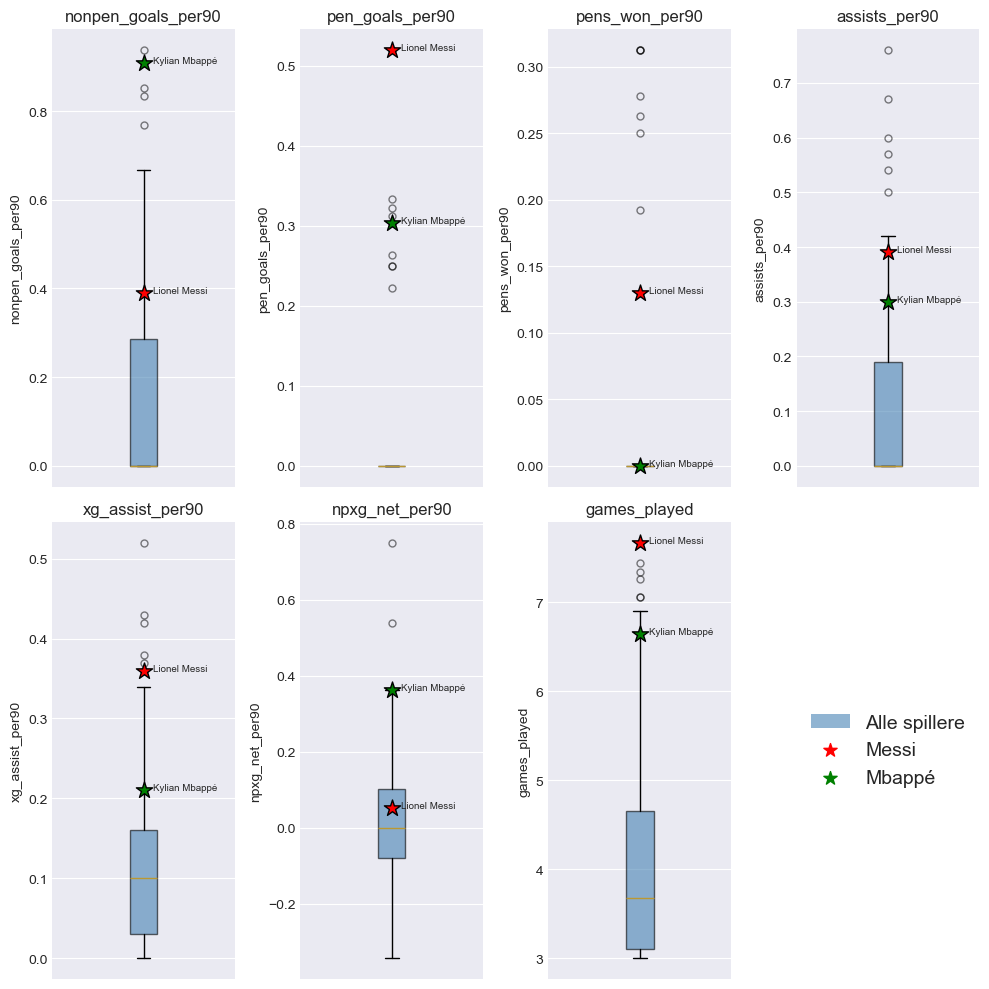

Feature-matrix form: (89, 7)


,count,mean,std,min,25%,50%,75%,max
nonpen_goals_per90,89.0,0.178210,0.238502,0.000000,0.000000,0.000000,0.285714,0.937500
pen_goals_per90,89.0,0.031194,0.097208,0.000000,0.000000,0.000000,0.000000,0.519481
pens_won_per90,89.0,0.023041,0.076015,0.000000,0.000000,0.000000,0.000000,0.312500
assists_per90,89.0,0.101685,0.182067,0.000000,0.000000,0.000000,0.190000,0.760000
xg_assist_per90,89.0,0.120225,0.115444,0.000000,0.030000,0.100000,0.160000,0.520000
npxg_net_per90,89.0,0.021346,0.167362,-0.342857,-0.078947,0.000000,0.101449,0.750000
games_played,89.0,4.172285,1.328808,3.000000,3.100000,3.677778,4.655556,7.666667


In [1131]:
feature_cols_v1 = [
    'nonpen_goals_per90',
    'pen_goals_per90',
    'pens_won_per90',
    'assists_per90',
    'xg_assist_per90',
    'npxg_net_per90',
    'games_played',
]

fig, axes = plt.subplots(2, 4, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols_v1):
    data = players_off[col].dropna()
    
    bp = axes[i].boxplot(data,
                         patch_artist=True,
                         flierprops=dict(marker='o', markersize=5, alpha=0.5))
    
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    
    for name, color in [('Messi', 'red'), ('Mbappé', 'green')]:
        mask = players_off['player'].str.contains(name, case=False, na=False)
        sub = players_off[mask]
        for _, row in sub.iterrows():
            axes[i].scatter(1, row[col],
                          color=color, edgecolor='black', s=150, marker='*', zorder=5)
            axes[i].text(1.05, row[col], row['player'], fontsize=7)
    
    axes[i].set_title(col)
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])

# Legend i den tomme 8. subplot
axes[-1].axis('off')
legend_elements = [Patch(facecolor='steelblue', alpha=0.6, label='Alle spillere'),
                   plt.scatter([], [], color='red', marker='*', s=100, label='Messi'),
                   plt.scatter([], [], color='green', marker='*', s=100, label='Mbappé')]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=14, frameon=False)

plt.tight_layout()
plt.show()

features_v1 = players_off[feature_cols_v1].copy()

# Udskift evt. NaN med 0 for per-90 stats (ingen events => 0)
features_v1 = features_v1.fillna(0.0)

print("Feature-matrix form:", features_v1.shape)
features_v1.describe().T

### Outliers og datakvalitet

Fra den deskriptive statistik ser jeg at nogle per90 features har meget høje maksimum værdier. `nonpen_goals_per90` har et maksimum på 0.938 og `npxg_net_per90` på 0.750. Dette skyldes primært spillere der har haft en ekstraordinær præstation i turneringen.

Jeg vælger bevidst ikke at fjerne disse outliers da de er reelle præstationer og ikke måle fejl. I denne kontekst er outliers præcis det jeg leder efter, nemlig spillere der skiller sig markant ud fra mængden. At fjerne dem ville ødelægge hele analysens formål. I stedet håndterer jeg statistisk usikkerhed via mine minimumskrav på 270 minutters spilletid, som sikrer at spillere med ekstremt små samples filtreres fra.

Manglende værdier opstår hvor en spiller ikke har nogen events i en given kategori. Disse sættes til 0, da fraværet af fx mål eller assists er en reel observation og ikke manglende data, men i det anvendte datasæt er alle værdier allerede udfyldt med numeriske observationer, hvor 0 forekommer i de tilfælde, hvor spilleren ikke har haft hændelser inden for den pågældende feature.

### Metode til at forstå hvor meget af en spillers score kommer fra hvilke vægtede features

In [1132]:
def explain_player_score(player_name, players_df, contributions_df, score_col):
    # Find spiller
    mask = players_df['player'].str.lower() == player_name.lower()
    if mask.sum() == 0:
        print(f"Ingen spiller fundet med navn: '{player_name}'")
        return
    
    idx = players_df[mask].index[0]
    player_contributions = contributions_df.loc[idx]
    
    positive = player_contributions[player_contributions >= 0]
    negative = player_contributions[player_contributions < 0]
    
    total_positive = positive.sum()
    total_negative = negative.sum()
    total_score = players_df.loc[idx, score_col]
    rank = players_df[score_col].rank(ascending=False).loc[idx]
    
    positive_pct = (positive / total_positive * 100).sort_values(ascending=False)
    negative_pct = (negative / abs(total_negative) * 100).sort_values(ascending=False)
    
    print(f"{'='*50}")
    print(f"Spiller:      {players_df.loc[idx, 'player']}")
    print(f"Rangering:    #{int(rank)}")
    print(f"Total score:  {total_score:.2f}")
    print(f"Positiv sum:  +{total_positive:.2f}")
    print(f"Negativ sum:  {total_negative:.2f}")
    print(f"{'='*50}")
    
    print("\n✅ Positive bidrag:")
    print(f"  {'Feature':<45} {'Point':>7}  {'%':>6}")
    print(f"  {'-'*60}")
    for feat, pct in positive_pct.items():
        points = positive[feat]
        bar = '█' * int(pct / 2)
        print(f"  {feat:<45} {points:>7.2f}  {pct:>5.1f}%  {bar}")
    
    print("\n❌ Negative bidrag:")
    print(f"  {'Feature':<45} {'Point':>7}  {'%':>6}")
    print(f"  {'-'*60}")
    for feat, pct in negative_pct.items():
        points = negative[feat]
        bar = '█' * int(pct / 2)
        print(f"  {feat:<45} {points:>7.2f}  {pct:>5.1f}%  {bar}")

# Stage 3 - Data Modeling

I dette afsnit har jeg bygget fire versioner af en vægtet offensiv algoritme/scoringsmodel (V1 til V4), hvor hver version tilføjer flere features baseret på hvad jeg lærte fra den forrige version.

For hver version følger jeg samme metodiske tilgang:
1. Definer feature sæt og vægte
2. Beregn vægtet score pr. spiller
3. Analyser score dekompositionen med `explain_player_score` for at forstå hvad der driver scoren og hvad der mangler
4. Træn en Random Forest regressionsmodel til at forudsige `nonpen_goals_per90` ud fra de øvrige features
5. Lav KMeans clustering for at identificere spillertyper baseret på silhouette scores
6. Valider clusterne med Random Forest klassifikation og confusion matrix for at bekræfte at grupperingen er meningsfuld

Modellen er en **vægtet lineær scoring** (weighted linear scoring) hvor hver feature ganges med en manuelt valgt vægt og summeres til en samlet score, har baseret vægtningerne ud fra vigtigheden forskellige events/features har for en kamp på baggrund af personlig viden og korspondance med flere forskelige ai's. Features normaliseres pr. 90 minutter for at sammenligne spillere på tværs af forskellig spilletid.

Målet er at finde den model der bedst rangerer spillere ud fra offensiv kvalitet samt nogle vigtige kvaliteter i generel kontrol af en fodboldkamp og dermed besvare om dataen peger på Mbappé eller Messi som turneringens bedste offensive/playmakende spiller.

## Offensiv score V1 - med de mest basale offensive features

Jeg starter med en simpel og gennemsigtig vægtning baseret på de mest grundlæggende offensive features.

I denne version bruges `npxg_net_per90` fra `player_shooting.csv` som et mål for om en spiller over eller underperformer sine forventede mål.

Vægtnings idéen er at mål uden straffe vægtes højest, straffemål vægtes lavere, trukne straffe vægtes moderat og chance skabelse via `xg_assist_per90` vægtes højt. Features multipliceres direkte med vægtene uden standardisering så scoren er direkte fortolkelig i råværdier.

In [1133]:
# V1 – baseline offensiv score (uden goals_assists_per90)
feature_cols_v1 = [
    # Output + chance-kvalitet (V1)
    'nonpen_goals_per90',
    'pen_goals_per90',
    'pens_won_per90',
    'assists_per90',
    'xg_assist_per90',
    'npxg_net_per90',
    'games_played',
]


feat_v1 = players_off[feature_cols_v1].copy().fillna(0.0)


weights_v1 = np.array([
    # Output + chance-kvalitet (V1)
    5.0,     # nonpen_goals_per90
    1.5,     # pen_goals_per90
    2.0,     # pens_won_per90
    2.0,     # assists_per90
    1.8,     # xg_assist_per90
    2.0,     # npxg_net_per90
    0.6,     # games_played
])

players_off['offensive_score'] = feat_v1 @ weights_v1

print("Top 10 efter offensiv score v1 (FW/MF, min 270 min):")
cols_show = ['player','team','position','minutes','goals','pens_made','pens_won','assists','offensive_score']
print(players_off.sort_values('offensive_score', ascending=False)[cols_show].head(10).to_string(index=False))

print("\nPlacering af Messi og Mbappé (v1):")
ranked_v1 = players_off.sort_values('offensive_score', ascending=False).reset_index(drop=True)
for name in ['Messi', 'Mbappé']:
    mask = ranked_v1['player'].str.contains(name, case=False, na=False)
    sub = ranked_v1[mask]
    if not sub.empty:
        for idx, row in sub.iterrows():
            print(
                f"{row['player']}: rank {idx+1}, score {row['offensive_score']:.2f}, "
                f"goals {row['goals']} (pens {row['pens_made']}), pens_won {row['pens_won']}, "
                f"assists {row['assists']}, minutes {row['minutes']}"
            )

Top 10 efter offensiv score v1 (FW/MF, min 270 min):
         player        team position  minutes  goals  pens_made  pens_won  assists  offensive_score
  Kylian Mbappé      France       FW      598      8          2       0.0        2        10.691939
   Lionel Messi   Argentina       FW      690      7          4       1.0        3         9.118909
    Bukayo Saka     England       FW      288      3          0       1.0        0         9.092500
 Julián Álvarez   Argentina       FW      464      4          0       1.0        0         7.898564
    Richarlison      Brazil       FW      323      3          0       1.0        0         7.861556
 Olivier Giroud      France       FW      419      4          0       0.0        0         7.357972
     Cody Gakpo Netherlands       FW      450      3          0       0.0        0         7.296000
Bruno Fernandes    Portugal       FW      356      2          1       0.0        3         6.624333
   Ivan Perišić     Croatia       FW      669  

#### Jeg kan ud fra denne liste se at det kun er angribere der får mange point

Jeg tager et kig på score dekompositionen for en midtbanespiller og en angriber for at forstå hvad der driver scoren og få et indblik i hvilke features jeg skal tilføje for at få en mere fair vurdering af spillere på tværs af positioner.

In [1134]:
# Byg contributions_df_v1
weighted_contributions_v1 = feat_v1 * weights_v1
weighted_contributions_df_v1 = pd.DataFrame(
 weighted_contributions_v1,
 columns=feature_cols_v1,
 index=players_off.index
)

explain_player_score("Antoine Griezmann", players_off, weighted_contributions_df_v1, 'offensive_score')
explain_player_score("Pedri", players_off, weighted_contributions_df_v1, 'offensive_score')
explain_player_score("Kylian Mbappé", players_off, weighted_contributions_df_v1, 'offensive_score')

Spiller:      Antoine Griezmann
Rangering:    #18
Total score:  5.28
Positiv sum:  +5.52
Negativ sum:  -0.23

✅ Positive bidrag:
  Feature                                         Point       %
  ------------------------------------------------------------
  games_played                                     3.58   64.9%  ████████████████████████████████
  assists_per90                                    1.00   18.1%  █████████
  xg_assist_per90                                  0.94   17.0%  ████████
  nonpen_goals_per90                               0.00    0.0%  
  pen_goals_per90                                  0.00    0.0%  
  pens_won_per90                                   0.00    0.0%  

❌ Negative bidrag:
  Feature                                         Point       %
  ------------------------------------------------------------
  npxg_net_per90                                  -0.23  -100.0%  
Spiller:      Pedri
Rangering:    #56
Total score:  2.77
Positiv sum:  +2.77
Negativ 

#### Jeg kan ud fra dette se at der skal tilføjes flere features

`games_played` dominerer scoren for de fleste midtbanespillere og de offensive midtbane specifikke features fylder for lidt. Jeg vil i næste version tilføje SCA features (shot creating actions) og pasningskvalitet for at give midtbanespillere flere muligheder for at score point på deres faktiske offensive bidrag.

## Regressionsmodel V1 - kan jeg forudsige målproduktion ud fra offensive features?

Jeg træner en Random Forest regressionsmodel V1 der forsøger at forudsige `nonpen_goals_per90` ud fra alle andre features i V1, altså uden at bruge målscoren selv som input.

V1 indeholder kun de mest basale offensive features som `pen_goals_per90`, `pens_won_per90`, `assists_per90`, `xg_assist_per90`, `npxg_net_per90` og `games_played`. Spørgsmålet er om disse få grundlæggende features er tilstrækkelige til at forudsige en spillers direkte målproduktion, eller om der er behov for mere detaljerede features.

Jeg evaluerer modellen med R2 som fortæller mig hvor stor en andel af variansen i målproduktionen modellen kan forklare, samt MSE som måler den gennemsnitlige kvadrerede fejl i forudsigelserne.

R2: 0.539
MSE: 0.020


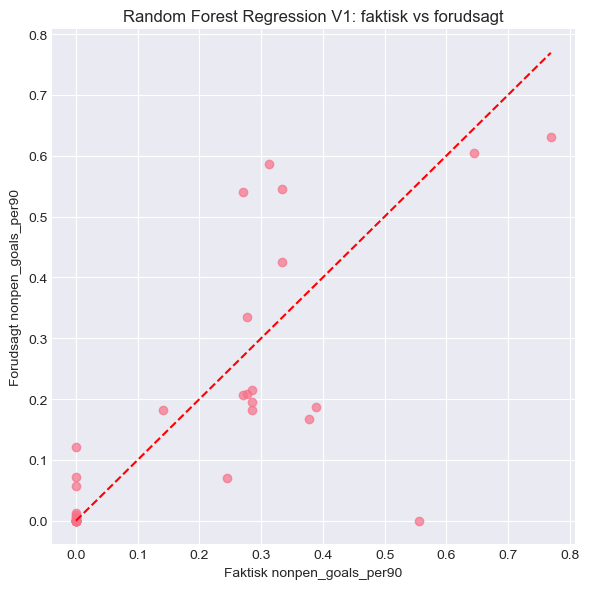

In [1135]:
feature_cols_reg_v1 = [c for c in feature_cols_v1 if c != 'nonpen_goals_per90']
X_reg_v1 = feat_v1[feature_cols_reg_v1]
y_reg_v1 = players_off['nonpen_goals_per90']

X_train_reg_v1, X_test_reg_v1, y_train_reg_v1, y_test_reg_v1 = train_test_split(
 X_reg_v1, y_reg_v1, test_size=0.4, random_state=42
)

rf_reg_v1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_v1.fit(X_train_reg_v1, y_train_reg_v1)
y_pred_reg_v1 = rf_reg_v1.predict(X_test_reg_v1)

print(f"R2: {r2_score(y_test_reg_v1, y_pred_reg_v1):.3f}")
print(f"MSE: {mean_squared_error(y_test_reg_v1, y_pred_reg_v1):.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg_v1, y_pred_reg_v1, alpha=0.7)
plt.plot([y_test_reg_v1.min(), y_test_reg_v1.max()],
 [y_test_reg_v1.min(), y_test_reg_v1.max()], 'r--')
plt.xlabel('Faktisk nonpen_goals_per90')
plt.ylabel('Forudsagt nonpen_goals_per90')
plt.title('Random Forest Regression V1: faktisk vs forudsagt')
plt.tight_layout()
plt.show()

### Resultater - Regressionsmodel V1

Modellen opnår en **R2 på 0.539** og en **MSE på 0.020**, hvilket betyder at modellen forklarer 53.9% af variansen i `nonpen_goals_per90` ud fra V1 features. Det er et moderat resultat som indikerer at de basale offensive features fanger en del af mønsteret, men at der er væsentlig variation som ikke kan forklares med så få features.

Plottet viser tydelig spredning rundt om den røde linje, særligt i midten af skalaen hvor modellen har sværest ved at forudsige præcist. Det tyder på at V1 features alene ikke er tilstrækkelige til at forudsige målproduktion præcist, og at der er behov for mere detaljerede features om skud, zoneinvolvering og boldkontrol.

In [1136]:
players_to_predict = ['Kylian Mbappé', 'Lionel Messi', 'Pedri', 'Bukayo Saka']
print("=" * 55)
print("Forudsagte vs faktiske nonpen_goals_per90")
print("=" * 55)
print(f"  {'Spiller':<25} {'Faktisk':>10} {'Forudsagt':>10}")
print(f"  {'-'*50}")
for name in players_to_predict:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        idx = sub.index[0]
        actual = y_reg_v1.loc[idx]
        predicted = rf_reg_v1.predict(X_reg_v1.loc[[idx]])[0]
        print(f"  {name:<25} {actual:>10.3f} {predicted:>10.3f}")
print("=" * 55)

Forudsagte vs faktiske nonpen_goals_per90
  Spiller                      Faktisk  Forudsagt
  --------------------------------------------------
  Kylian Mbappé                  0.909      0.775
  Lionel Messi                   0.390      0.187
  Pedri                          0.000      0.122
  Bukayo Saka                    0.938      0.861


### Eksempler på forudsigelser

Modellen fanger den relative rangorden delvist korrekt med Mbappé og Saka som de højeste. Saka forudsiges meget tæt på hans faktiske værdi, mens Mbappé undervurderes en smule. Messi forudsiges væsentligt lavere end hans faktiske værdi, og Pedri overvurderes med 0.122 på trods af at han ikke scorede nogen mål. Det tyder på at modellen med V1 features ikke klart nok kan skelne mellem spillere der skaber mange chancer uden selv at score og spillere der rent faktisk konverterer dem til mål.

## Clustering af offensive profiler V1

Nu vil jeg ikke bare rangere spillere men også se hvilke **profiler** der findes i dataen. Hvilke typer angribere og midtbaner er der i turneringen, og ligner Messi og Mbappé hinanden statistisk eller ligger de i forskellige klynger?

Jeg bruger **KMeans** clustering på de skalerede V1 features og vælger det antal clusters der giver den højeste silhouette score.

In [1137]:
scaler_v1 = StandardScaler()
X_v1 = scaler_v1.fit_transform(feat_v1)

# Clustering på v2 features
range_k = range(2, 10)
print("Silhouette scores (v1 features):")
for k in range_k:
 km = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = km.fit_predict(X_v1)
 score = silhouette_score(X_v1, labels)
 print(f"k={k}: silhouette={score:.3f}")

Silhouette scores (v1 features):
k=2: silhouette=0.410
k=3: silhouette=0.342
k=4: silhouette=0.257
k=5: silhouette=0.317
k=6: silhouette=0.347
k=7: silhouette=0.369
k=8: silhouette=0.367
k=9: silhouette=0.367


#### Jeg kan ud fra silhouette scores se at clusterne er mest adskilte ved k=2

Alle scores falder fra 0.410 ved k=2, hvilket indikerer at spillerne ikke danner mange naturlige grupper ud fra de basale V1 features. Jeg går videre med k=2 som den mest statistisk forsvarlige opdeling og undersøger om Messi og Mbappé havner i samme cluster.

In [1138]:
best_k = 2
kmeans_v1 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
players_off['cluster_v1'] = kmeans_v1.fit_predict(X_v1)

print("Cluster_v1-fordeling:")
print(players_off['cluster_v1'].value_counts().sort_index())

print("\nMessi og Mbappé cluster_v1:")
for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        for _, row in sub.iterrows():
            print(f"{row['player']}: cluster_v1 {row['cluster_v1']}, score_v1 {row['offensive_score']:.2f}")

Cluster_v1-fordeling:
cluster_v1
0    70
1    19
Name: count, dtype: int64

Messi og Mbappé cluster_v1:
Lionel Messi: cluster_v1 1, score_v1 9.12
Kylian Mbappé: cluster_v1 1, score_v1 10.69


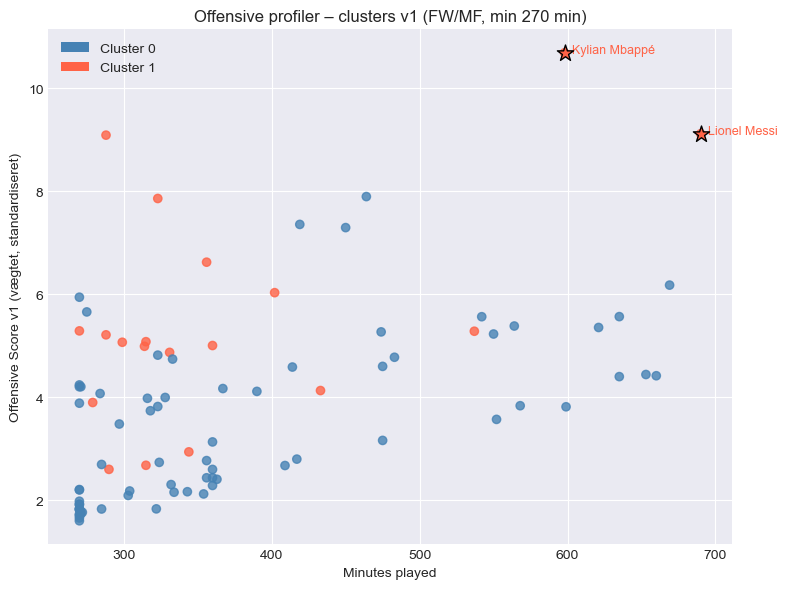

cluster_v1,0,1
nonpen_goals_per90,0.142225,0.310784
pen_goals_per90,0.000000,0.146121
pens_won_per90,0.002747,0.097806
assists_per90,0.040429,0.327368
xg_assist_per90,0.081571,0.262632
npxg_net_per90,0.021727,0.019944
games_played,4.188571,4.112281


In [1139]:
# Simpel visualisering: offensive_score_v2 vs minutes farvet efter cluster_v2
colors = ['steelblue', 'tomato']

plt.figure(figsize=(8,6))
plt.scatter(
    players_off['minutes'],
    players_off['offensive_score'],
    c=players_off['cluster_v1'].map({0: colors[0], 1: colors[1]}),
    alpha=0.8
)
plt.xlabel('Minutes played')
plt.ylabel('Offensive Score v1 (vægtet, standardiseret)')
plt.title('Offensive profiler – clusters v1 (FW/MF, min 270 min)')

legend_elements = [Patch(facecolor=colors[0], label='Cluster 0'),
                   Patch(facecolor=colors[1], label='Cluster 1')]
plt.legend(handles=legend_elements)

for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    for _, row in sub.iterrows():
        cluster_color = colors[row['cluster_v1']]
        plt.scatter(row['minutes'], row['offensive_score'],
                    color=cluster_color, edgecolor='black', s=150, marker='*', zorder=5)
        plt.text(row['minutes']+5, row['offensive_score'],
                 row['player'], fontsize=9, color=cluster_color)

plt.tight_layout()
plt.show()

# Se hvad der kendetegner hvert cluster
players_off.groupby('cluster_v1')[feature_cols_v1].mean().T

### Cluster beskrivelser (V1, k=2)

- ### Cluster 0 - Den solide bidragsyder
	Moderate tal på tværs af alle features. Spiller mange kampe men uden at dominere offensivt. Lav på mål, assists og straffe. Sandsynligvis spillere der er med i truppen men ikke er primære offensive kræfter.

- ### Cluster 1 - Den direkte offensive spiller
	Højest på alt herunder mål, assists, straffe og `xg_assist`. Kommer til straffe og leverer både mål og assists. Kan være både angribere og offensive midtbanespillere der er direkte involveret i målproduktionen.

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.75      0.75      0.75         4

    accuracy                           0.89        18
   macro avg       0.84      0.84      0.84        18
weighted avg       0.89      0.89      0.89        18



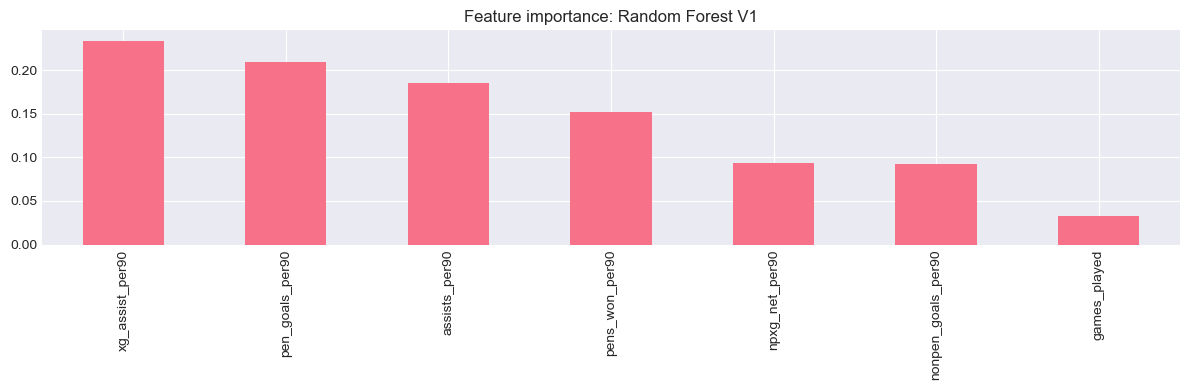

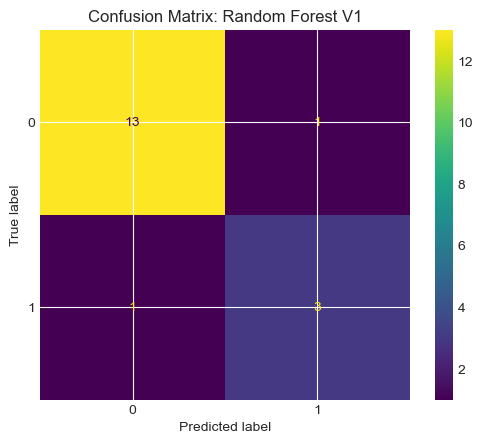

In [1140]:

X_clf_v1 = feat_v1
y_clf_v1 = players_off['cluster_v1']

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
 X_clf_v1, y_clf_v1, test_size=0.2, random_state=42
)

rf_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v1.fit(X_train_v1, y_train_v1)

y_pred_v1 = rf_v1.predict(X_test_v1)
print(classification_report(y_test_v1, y_pred_v1))

importances_v1 = pd.Series(rf_v1.feature_importances_, index=feat_v1.columns)
importances_v1.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Feature importance: Random Forest V1')
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test_v1, y_pred_v1)
plt.title('Confusion Matrix: Random Forest V1')
plt.show()


### Random Forest validering - clusterne er meningsfulde og lærbare

Random Forest klassifikatoren opnår **89% accuracy** på test sættet, hvilket bekræfter at de to clusters ikke er tilfældige grupperinger. Der er et reelt og lærbart mønster i måden KMeans har opdelt spillerne selv med kun 7 basale features.

Feature importance plottet viser hvilke features der bedst adskiller de to clusters. `xg_assist_per90` er den vigtigste feature tæt efterfulgt af `pen_goals_per90` og `assists_per90`. Det fortæller os at det primært er chance skabelse og direkte målproduktion der adskiller den direkte offensive spiller fra den solide bidragsyder. `pens_won_per90` bidrager også markant, hvilket bekræfter at evnen til at provokere straffe er et stærkt signal for den offensive spillertype. `nonpen_goals_per90` og `npxg_net_per90` bidrager mindst, mens `games_played` næsten ikke bidrager overhovedet. Antal kampe alene er altså ikke et meningsfuldt signal for hvilken type spiller man er.

Confusion matrixen viser at modellen klassificerer 13 ud af 14 spillere i Cluster 0 korrekt, og 3 ud af 4 spillere i Cluster 1 korrekt. Der er en fejlklassificering i hver retning. Dette svarer til den 89% accuracy jeg så i classification_report og bekræfter at modellen allerede med kun 7 basale features er i stand til at skelne meningsfuldt mellem de to spillertyper.

## Offensiv score V2 - med SCA features og pasningskvalitet

Jeg udvider scoringen med flere detaljerede offensive features. Jeg tilføjer shot creating actions via `sca_shots_per90`, `sca_dribbles_per90` og `sca_fouled_per90` som måler hvordan en spiller skaber skud chancer via skud, driblinger og frispark. Jeg tilføjer også pasningskvalitet via `pass_completion_factor_per90` hvor `pass_completion_factor = passes_completed * (passes_completed_pct/100)`

In [1141]:
# V2 – udvidet features med SCA og pasninger
feature_cols_v2 = [
    # Output + chance-kvalitet (V1)
    'nonpen_goals_per90',
    'pen_goals_per90',
    'pens_won_per90',
    'assists_per90',
    'xg_assist_per90',
    'npxg_net_per90',
    'games_played',
    
    # Proces (SCA) (V2)
    'sca_shots_per90',
    'sca_dribbles_per90',
    'sca_fouled_per90',
    # Pasningskvalitet (V2)
    'pass_completion_factor_per90',
]

feat_v2 = players_off[feature_cols_v2].copy().fillna(0.0)

weights_v2 = np.array([
    # Output + chance-kvalitet (V1)
    5.0,     # nonpen_goals_per90
    1.5,     # pen_goals_per90
    2.0,     # pens_won_per90
    2.0,     # assists_per90
    1.8,     # xg_assist_per90
    2.0,     # npxg_net_per90
    0.6,     # games_played
    
    # Proces (SCA) (V2)
    0.3,     # sca_shots_per90
    0.6,     # sca_dribbles_per90
    0.3,     # sca_fouled_per90
    
    # Pasningskvalitet
    0.03,    # pass_completion_factor_per90
])

players_off['offensive_score_v2'] = feat_v2 @ weights_v2

print('Top 10 efter offensiv score v2 (FW/MF, min 270 min):')
cols_show_v2 = ['player','team','position','minutes','goals','pens_made','pens_won','assists','offensive_score_v2']
print(players_off.sort_values('offensive_score_v2', ascending=False)[cols_show_v2].head(10).to_string(index=False))

print('\nPlacering af Messi og Mbappé (score v2):')
ranked_v2 = players_off.sort_values('offensive_score_v2', ascending=False).reset_index(drop=True)
for name in ['Messi', 'Mbappé']:
    mask = ranked_v2['player'].str.contains(name, case=False, na=False)
    sub = ranked_v2[mask]
    if not sub.empty:
        for idx, row in sub.iterrows():
            print(
                f"{row['player']}: rank {idx+1}, score_v2 {row['offensive_score_v2']:.2f}, "
                f"goals {row['goals']} (pens {row['pens_made']}), pens_won {row['pens_won']}, "
                f"assists {row['assists']}, minutes {row['minutes']}"
            )

Top 10 efter offensiv score v2 (FW/MF, min 270 min):
             player        team position  minutes  goals  pens_made  pens_won  assists  offensive_score_v2
      Kylian Mbappé      France       FW      598      8          2       0.0        2           12.376553
       Lionel Messi   Argentina       FW      690      7          4       1.0        3           10.535178
        Bukayo Saka     England       FW      288      3          0       1.0        0           10.080175
     Julián Álvarez   Argentina       FW      464      4          0       1.0        0            8.484239
        Richarlison      Brazil       FW      323      3          0       1.0        0            8.258222
         Cody Gakpo Netherlands       FW      450      3          0       0.0        0            7.826424
    Bruno Fernandes    Portugal       FW      356      2          1       0.0        3            7.762203
     Olivier Giroud      France       FW      419      4          0       0.0        0     

#### Jeg kan ud fra denne liste se at det stadigvæk mest er angribere der får mange point

Jeg tager et kig på score dekompositionen for en midtbanespiller og en angriber for at forstå hvad der stadig mangler og få et indblik i hvilke features jeg skal tilføje i næste version for at få en mere fair vurdering på tværs af positioner.

In [1142]:
# Byg contributions_df_v2
weighted_contributions_v2 = feat_v2 * weights_v2
weighted_contributions_df_v2 = pd.DataFrame(
 weighted_contributions_v2,
 columns=feature_cols_v2,
 index=players_off.index
)

explain_player_score("Pedri", players_off, weighted_contributions_df_v2, 'offensive_score_v2')
explain_player_score("Kylian Mbappé", players_off, weighted_contributions_df_v2, 'offensive_score_v2')

Spiller:      Pedri
Rangering:    #36
Total score:  5.44
Positiv sum:  +5.44
Negativ sum:  0.00

✅ Positive bidrag:
  Feature                                         Point       %
  ------------------------------------------------------------
  pass_completion_factor_per90                     2.67   49.1%  ████████████████████████
  games_played                                     2.37   43.6%  █████████████████████
  xg_assist_per90                                  0.40    7.3%  ███
  nonpen_goals_per90                               0.00    0.0%  
  pen_goals_per90                                  0.00    0.0%  
  pens_won_per90                                   0.00    0.0%  
  assists_per90                                    0.00    0.0%  
  npxg_net_per90                                   0.00    0.0%  
  sca_shots_per90                                  0.00    0.0%  
  sca_dribbles_per90                               0.00    0.0%  
  sca_fouled_per90                               

#### Jeg kan ud fra dette se at der skal tilføjes flere features

`pass_completion_factor_per90` og `games_played` dominerer stadig scoren for midtbanespillere, og de egentlige playmaking features som boldmodtagelse og progressive pas har vi slet ikke med. Jeg vil i næste version tilføje possession features og dribble kvalitet for at give midtbanespillere der er involveret i opbygningen bedre mulighed for at score point på deres faktiske offensive bidrag.

## Regressionsmodel V2 - kan jeg forudsige målproduktion ud fra offensive features?

Jeg træner nu en Random Forest regressionsmodel V2, men nu på V2 features. V2 udvider V1 med shot creating actions som `sca_shots_per90`, `sca_dribbles_per90` og `sca_fouled_per90`, samt pasningskvalitet via `pass_completion_factor_per90`.

Spørgsmålet er om disse ekstra proces features der beskriver hvordan en spiller skaber situationer frem for blot outputtet, forbedrer modellens evne til at forudsige direkte målproduktion sammenlignet med V1.

Jeg evaluerer modellen med R2 og MSE og sammenligner med V1 resultatet for at vurdere om de ekstra features bidrager med reel forklaringskraft.

R2: 0.617
MSE: 0.016


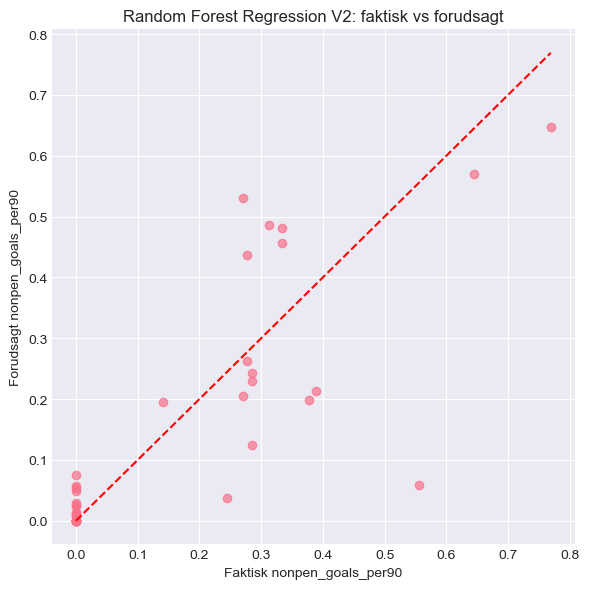

In [1143]:
feature_cols_reg_v2 = [c for c in feature_cols_v2 if c != 'nonpen_goals_per90']
X_reg_v2 = feat_v2[feature_cols_reg_v2]
y_reg_v2 = players_off['nonpen_goals_per90']

X_train_reg_v2, X_test_reg_v2, y_train_reg_v2, y_test_reg_v2 = train_test_split(
 X_reg_v2, y_reg_v2, test_size=0.4, random_state=42
)

rf_reg_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_v2.fit(X_train_reg_v2, y_train_reg_v2)
y_pred_reg_v2 = rf_reg_v2.predict(X_test_reg_v2)

print(f"R2: {r2_score(y_test_reg_v2, y_pred_reg_v2):.3f}")
print(f"MSE: {mean_squared_error(y_test_reg_v2, y_pred_reg_v2):.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg_v2, y_pred_reg_v2, alpha=0.7)
plt.plot([y_test_reg_v2.min(), y_test_reg_v2.max()],
 [y_test_reg_v2.min(), y_test_reg_v2.max()], 'r--')
plt.xlabel('Faktisk nonpen_goals_per90')
plt.ylabel('Forudsagt nonpen_goals_per90')
plt.title('Random Forest Regression V2: faktisk vs forudsagt')
plt.tight_layout()
plt.show()


### Resultater - Regressionsmodel V2

Modellen opnår en **R2 på 0.617** og en **MSE på 0.016**, hvilket betyder at modellen forklarer 61.7% af variansen i `nonpen_goals_per90` ud fra V2 features. Det er en forbedring fra V1's R2 på 0.539, hvilket bekræfter at de ekstra SCA og pasnings features bidrager med reel forklaringskraft udover de basale V1 features.

Plottet viser stadig spredning rundt om den røde linje, men punkterne følger linjen lidt tættere end i V1. Modellen har fortsat sværest ved at forudsige de spillere med meget høj faktisk målrate, som undervurderes i den høje ende af skalaen.

In [1144]:
players_to_predict = ['Kylian Mbappé', 'Lionel Messi', 'Pedri', 'Bukayo Saka']
print("=" * 55)
print("Forudsagte vs faktiske nonpen_goals_per90")
print("=" * 55)
print(f"  {'Spiller':<25} {'Faktisk':>10} {'Forudsagt':>10}")
print(f"  {'-'*50}")
for name in players_to_predict:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        idx = sub.index[0]
        actual = y_reg_v2.loc[idx]
        predicted = rf_reg_v2.predict(X_reg_v2.loc[[idx]])[0]
        print(f"  {name:<25} {actual:>10.3f} {predicted:>10.3f}")
print("=" * 55)


Forudsagte vs faktiske nonpen_goals_per90
  Spiller                      Faktisk  Forudsagt
  --------------------------------------------------
  Kylian Mbappé                  0.909      0.773
  Lionel Messi                   0.390      0.214
  Pedri                          0.000      0.053
  Bukayo Saka                    0.938      0.771


### Eksempler på forudsigelser

Modellen fanger den relative rangorden korrekt med Mbappé og Saka som de højeste målscorere og Pedri tæt på nul. Sammenlignet med V1 er Pedris forudsigelse faldet fra 0.122 til 0.053, hvilket viser at de ekstra features hjælper modellen med bedre at skelne mellem spillere der skaber chancer og spillere der rent faktisk scorer. Messi forudsiges stadig lavere end hans faktiske værdi men tættere end i V1.

## Clustering af offensive profiler V2

Jeg laver nu clustering på V2 features for at se om de ekstra SCA og pasnings features ændrer på hvilke spillertyper der identificeres, og om Messi og Mbappé fortsat havner i samme cluster som i V1.

Jeg bruger **KMeans** clustering på de vægtede V2 features og vælger det antal clusters der giver den højeste silhouette score.

In [1145]:
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(feat_v2)

# Clustering på v2 features
range_k = range(2, 10)
print("Silhouette scores (v2 features):")
for k in range_k:
 km = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = km.fit_predict(X_v2)
 score = silhouette_score(X_v2, labels)
 print(f"k={k}: silhouette={score:.3f}")

Silhouette scores (v2 features):
k=2: silhouette=0.364
k=3: silhouette=0.265
k=4: silhouette=0.250
k=5: silhouette=0.191
k=6: silhouette=0.205
k=7: silhouette=0.205
k=8: silhouette=0.163
k=9: silhouette=0.213


#### Jeg kan ud fra silhouette scores se at clusterne er mest adskilte ved k=2

Alle scores falder fra 0.364 ved k=2, hvilket indikerer at spillerne ikke danner skarpe naturlige grupper selv med de ekstra SCA og pasnings features i V2. Jeg går videre med k=2 som den mest statistisk forsvarlige opdeling og undersøger om Messi og Mbappé fortsat havner i samme cluster.

In [1146]:
best_k = 2
kmeans_v2 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
players_off['cluster_v2'] = kmeans_v2.fit_predict(X_v2)

print("Cluster_v2 fordeling:")
print(players_off['cluster_v2'].value_counts().sort_index())

print("\nMessi og Mbappé cluster_v2:")
for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        for _, row in sub.iterrows():
            print(f"{row['player']}: cluster_v2 {row['cluster_v2']}, score_v2 {row['offensive_score_v2']:.2f}")

Cluster_v2 fordeling:
cluster_v2
0    72
1    17
Name: count, dtype: int64

Messi og Mbappé cluster_v2:
Lionel Messi: cluster_v2 1, score_v2 10.54
Kylian Mbappé: cluster_v2 1, score_v2 12.38


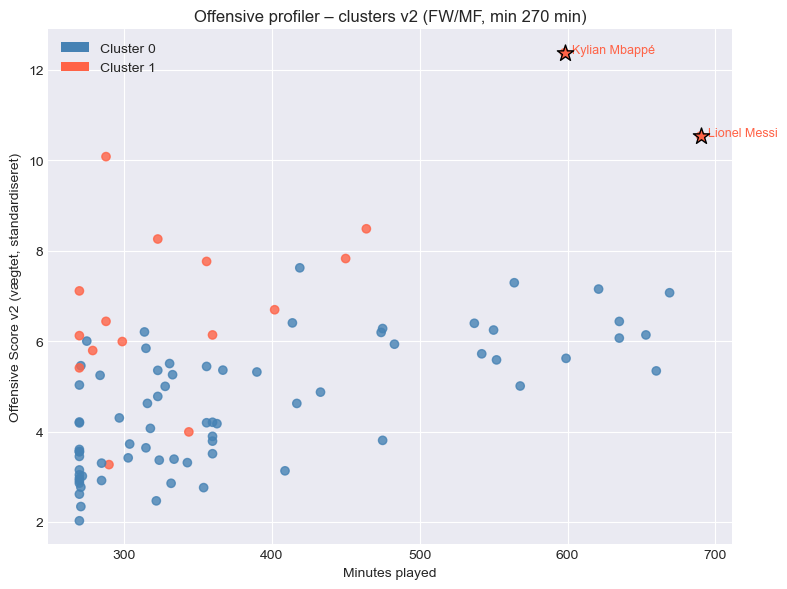

cluster_v2,0,1
nonpen_goals_per90,0.117059,0.437202
pen_goals_per90,0.000000,0.163312
pens_won_per90,0.000000,0.120624
assists_per90,0.075556,0.212353
xg_assist_per90,0.102361,0.195882
npxg_net_per90,-0.005044,0.133113
games_played,4.194290,4.079085
sca_shots_per90,0.160485,0.369486
sca_dribbles_per90,0.077610,0.352104
sca_fouled_per90,0.077453,0.447620


In [1147]:
# Simpel visualisering: offensive_score_v2 vs minutes farvet efter cluster_v2
colors = ['steelblue', 'tomato']

plt.figure(figsize=(8,6))
plt.scatter(
    players_off['minutes'],
    players_off['offensive_score_v2'],
    c=players_off['cluster_v2'].map({0: colors[0], 1: colors[1]}),
    alpha=0.8
)
plt.xlabel('Minutes played')
plt.ylabel('Offensive Score v2 (vægtet, standardiseret)')
plt.title('Offensive profiler – clusters v2 (FW/MF, min 270 min)')

legend_elements = [Patch(facecolor=colors[0], label='Cluster 0'),
                   Patch(facecolor=colors[1], label='Cluster 1')]
plt.legend(handles=legend_elements)

for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    for _, row in sub.iterrows():
        cluster_color = colors[row['cluster_v2']]
        plt.scatter(row['minutes'], row['offensive_score_v2'],
                    color=cluster_color, edgecolor='black', s=150, marker='*', zorder=5)
        plt.text(row['minutes']+5, row['offensive_score_v2'],
                 row['player'], fontsize=9, color=cluster_color)

plt.tight_layout()
plt.show()

# Se hvad der kendetegner hvert cluster
players_off.groupby('cluster_v2')[feature_cols_v2].mean().T

### Cluster beskrivelser (V2, k=2)

- ### Cluster 0 - Den solide holdspiller
	Moderate tal på tværs af alle features. Høj `pass_completion_factor` tyder på en sikker pasningsspiller. Ingen straffe. Sandsynligvis midtbanespillere der bidrager stabilt men ikke er afgørende i den direkte målproduktion.

- ### Cluster 1 - Den direkte offensive profil
	Højest på absolut alt offensivt. Scorer non pen mål, kommer til straffe, leverer assists og skaber chancer via driblinger og frispark. Positiv `npxg_net` bekræfter at han overperformer sine forventede mål. Lav `pass_completion_factor` bekræfter at han tager risici med bolden frem for at spille sikkert. Kan være både angribere og offensive midtbanespillere der er direkte involveret i mål og chancer.

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       0.50      1.00      0.67         2

    accuracy                           0.94        36
   macro avg       0.75      0.97      0.82        36
weighted avg       0.97      0.94      0.95        36



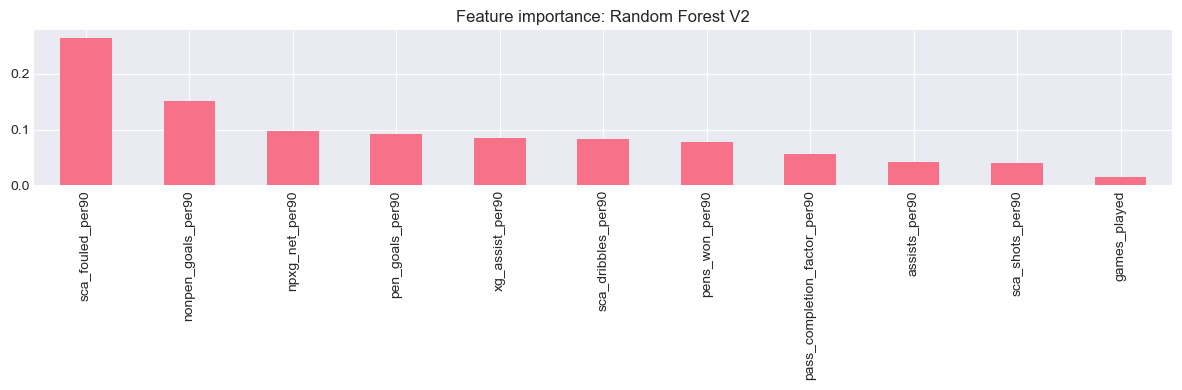

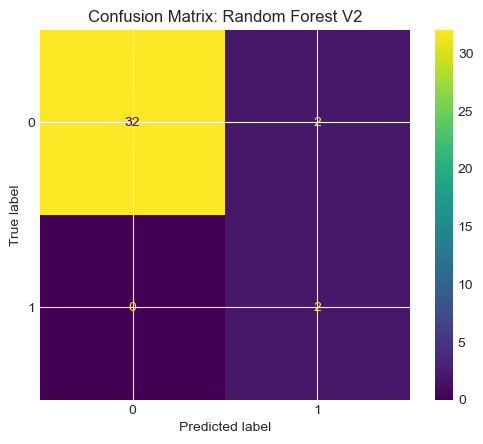

In [1148]:
X_clf_v2 = feat_v2
y_clf_v2 = players_off['cluster_v2']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
 X_clf_v2, y_clf_v2, test_size=0.4, random_state=42
)

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = rf_v2.predict(X_test_v2)
print(classification_report(y_test_v2, y_pred_v2))

importances = pd.Series(rf_v2.feature_importances_, index=feat_v2.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Feature importance: Random Forest V2')
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test_v2, y_pred_v2)
plt.title('Confusion Matrix: Random Forest V2')
plt.show()

### Random Forest validering - clusterne er meningsfulde og lærbare

Random Forest klassifikatoren opnår **94% accuracy** på test sættet, en forbedring fra V1's 89%, hvilket tyder på at de ekstra SCA og pasnings features i V2 gør clusterne lettere at adskille. Der er dog kun 2 spillere fra cluster 1 i test sættet, så recall på 1.00 skal tolkes med forsigtighed.

Feature importance plottet viser hvilke features der bedst adskiller de to clusters. `sca_fouled_per90` er den vigtigste feature, hvilket er interessant da denne feature ikke fandtes i V1. Det fortæller os at evnen til at provokere frispark er et stærkt signal for den direkte offensive spillertype. `pen_goals_per90` og `pens_won_per90` er næst vigtigst og bekræfter mønsteret fra V1 om at strafferelaterede features driver opdelingen. Feature importance er mere jævnt fordelt end i V1 hvor `xg_assist_per90` dominerede klart, hvilket tyder på at de ekstra features i V2 giver modellen flere ligeværdige signaler at arbejde med.

Confusion matrixen bekræfter resultatet. Modellen klassificerer alle 2 spillere i Cluster 1 korrekt, men misser 2 af 34 spillere i Cluster 0 i test sættet. Det perfekte recall for Cluster 1 skyldes ikke med garanti at modellen er perfekt, men at der kun er 2 spillere i Cluster 1 i test sættet, hvilket gør det svært at evaluere meningsfuldt på den gruppe alene.

## Offensiv score V3 - possession, modtagelser, dribbles og boldtab

V3 udvider V2 med flere involvement og ball security features fra `player_possession.csv`. Jeg tilføjer `touches_per90`, `passes_received_per90` og `progressive_passes_received_per90` som måler hvor involveret en spiller er i opbygningen. Jeg tilføjer også dribble kvalitet via `weighted_dribbles_completed_per90` hvor `weighted_dribbles_completed = dribbles_completed * (dribbles_completed_pct/100)`.

For at straffe spillere der mister bolden ofte tilføjer jeg `miscontrols_per90` og `dispossessed_per90` med negative vægte.

Ideen er at en *Player of the Tournament* typisk både producerer output, skaber chancer og er højt involveret, men samtidig ikke mister bolden ekstremt ofte.

In [1149]:
feature_cols_v3 = [
    # Output + chance-kvalitet (V1)
    'nonpen_goals_per90',
    'pen_goals_per90',
    'pens_won_per90',
    'assists_per90',
    'xg_assist_per90',
    'npxg_net_per90',
    'games_played',
    
    # Proces (SCA) (V2)
    'sca_shots_per90',
    'sca_dribbles_per90',
    'sca_fouled_per90',
    # Pasningskvalitet (V2)
    'pass_completion_factor_per90',
    
    # Involvement (V3)
    'touches_per90',
    'passes_received_per90',
    'progressive_passes_received_per90',
    # Dribble-kvalitet (V3)
    'weighted_dribbles_completed_per90',
    # Boldtab / Negative ball losses (V3)
    'miscontrols_per90',
    'dispossessed_per90',
]

feat_v3 = players_off[feature_cols_v3].copy().fillna(0.0)

# Vægte (samme rækkefølge som feature_cols_v3)
weights_v3 = np.array([
    # Output + chance-kvalitet (V1)
    5.0,     # nonpen_goals_per90
    1.5,     # pen_goals_per90
    2.0,     # pens_won_per90
    2.0,     # assists_per90
    1.8,     # xg_assist_per90
    2.0,     # npxg_net_per90
    0.6,     # games_played
    
    # Proces (SCA) (V2)
    0.3,     # sca_shots_per90
    0.6,     # sca_dribbles_per90
    0.3,     # sca_fouled_per90
    
    # Pasningskvalitet
    0.03,    # pass_completion_factor_per90
    
    # Involvement (V3)
    0.05,   # touches_per90
    0.05,    # passes_received_per90
    0.75,    # progressive_passes_received_per90
    
    # Dribble-kvalitet
    0.8,     # weighted_dribbles_completed_per90
    
    # Negative ball losses
    -0.6,    # miscontrols_per90
    -0.9,    # dispossessed_per90
])

players_off['offensive_score_v3'] = feat_v3 @ weights_v3

print('Top 10 efter offensiv score v3 (FW/MF, min 270 min):')
cols_show_v3 = ['player','team','position','minutes','goals','pens_made','pens_won','assists','offensive_score_v3']
print(players_off.sort_values('offensive_score_v3', ascending=False)[cols_show_v3].head(10).to_string(index=False))

print('\nPlacering af Messi og Mbappé (score v3):')
ranked_v3 = players_off.sort_values('offensive_score_v3', ascending=False).reset_index(drop=True)
for name in ['Messi', 'Mbappé']:
    mask = ranked_v3['player'].str.contains(name, case=False, na=False)
    sub = ranked_v3[mask]
    if not sub.empty:
        for idx, row in sub.iterrows():
            print(
                f"{row['player']}: rank {idx+1}, score_v3 {row['offensive_score_v3']:.2f}, "
                f"goals {row['goals']} (pens {row['pens_made']}), pens_won {row['pens_won']}, assists {row['assists']}, minutes {row['minutes']}"
            )


Top 10 efter offensiv score v3 (FW/MF, min 270 min):
          player      team position  minutes  goals  pens_made  pens_won  assists  offensive_score_v3
   Kylian Mbappé    France       FW      598      8          2       0.0        2           21.599280
     Bukayo Saka   England       FW      288      3          0       1.0        0           18.186800
           Pedri     Spain       MF      356      0          0       0.0        0           16.768768
    Lionel Messi Argentina       FW      690      7          4       1.0        3           16.060113
  Ángel Di María Argentina       MF      288      1          0       1.0        1           15.877063
 Jude Bellingham   England       MF      414      1          0       0.0        1           15.624033
       Dani Olmo     Spain       FW      367      1          0       0.0        1           15.266784
 Bruno Fernandes  Portugal       FW      356      2          1       0.0        3           15.212203
Marcelo Brozović   Croatia   

#### Jeg kan ud fra denne liste se at det nu er ret jævnt fordelt mellem midtbaner og angribere der får mange point

Jeg tager et kig på score dekompositionen for en midtbanespiller og en angriber for at forstå hvad der stadig driver scoren og få et indblik i hvilke features jeg kan forbedre i næste version.

In [1150]:
# Byg contributions_df_v3
weighted_contributions_v3 = feat_v3 * weights_v3
weighted_contributions_df_v3 = pd.DataFrame(
 weighted_contributions_v3,
 columns=feature_cols_v3,
 index=players_off.index
)

explain_player_score("Pedri", players_off, weighted_contributions_df_v3, 'offensive_score_v3')
explain_player_score("Luka Modrić", players_off, weighted_contributions_df_v3, 'offensive_score_v3')
explain_player_score("Kylian Mbappé", players_off, weighted_contributions_df_v3, 'offensive_score_v3')
explain_player_score("Lionel Messi", players_off, weighted_contributions_df_v3, 'offensive_score_v3')

Spiller:      Pedri
Rangering:    #3
Total score:  16.77
Positiv sum:  +18.49
Negativ sum:  -1.73

✅ Positive bidrag:
  Feature                                         Point       %
  ------------------------------------------------------------
  touches_per90                                    5.78   31.2%  ███████████████
  passes_received_per90                            4.94   26.7%  █████████████
  pass_completion_factor_per90                     2.67   14.4%  ███████
  games_played                                     2.37   12.8%  ██████
  progressive_passes_received_per90                1.69    9.1%  ████
  weighted_dribbles_completed_per90                0.65    3.5%  █
  xg_assist_per90                                  0.40    2.1%  █
  nonpen_goals_per90                               0.00    0.0%  
  pen_goals_per90                                  0.00    0.0%  
  pens_won_per90                                   0.00    0.0%  
  assists_per90                                 

#### Jeg kan ud fra dette se at der skal tilføjes flere features

`touches_per90` og `passes_received_per90` dominerer stadig scoren for midtbanespillere selvom de er lavt vægtet. Jeg vil i næste version tilføje mere direkte offensive features som skud, zoneinvolvering og defensive bidrag, samt stærkere negative features for fejl og kort, så modellen bliver mere præcis og balanceret på tværs af spillertyper.

## Regressionsmodel V3 - kan jeg forudsige målproduktion ud fra offensive features?

Jeg træner nu en Random Forest regressionsmodel V3 der forsøger at forudsige `nonpen_goals_per90` ud fra alle andre features i V3, altså uden at bruge målscoren selv som input.

V3 inkluderer possession features som `touches_per90`, `passes_received_per90`, `progressive_passes_received_per90` og dribble kvalitet via `weighted_dribbles_completed_per90`. Spørgsmålet er om en spillers involvering, boldkontrol og dribble evner er tilstrækkelige til at forudsige hans direkte målproduktion.

Formålet er at undersøge om de offensive features jeg har tilføjet i V3 fanger noget reelt om hvem der ender med at score mål, eller om der mangler mere direkte skud og zoneinvolverings features for at forudsige målproduktion præcist.

Jeg evaluerer modellen med R2 som fortæller mig hvor stor en andel af variansen i målproduktionen modellen kan forklare, samt MSE som måler den gennemsnitlige kvadrerede fejl i forudsigelserne.

R2: 0.659
MSE: 0.016


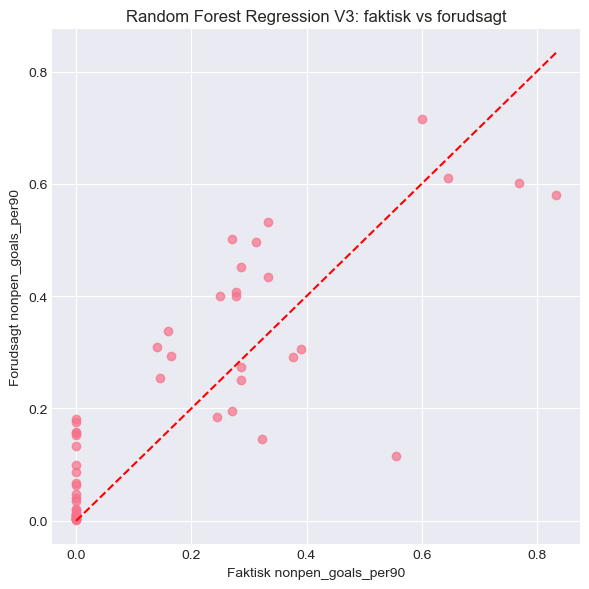

In [1151]:
feature_cols_reg_v3 = [c for c in feature_cols_v3 if c != 'nonpen_goals_per90']

X_reg_v3 = feat_v3[feature_cols_reg_v3]
y_reg_v3 = players_off['nonpen_goals_per90']

X_train_reg_v3, X_test_reg_v3, y_train_reg_v3, y_test_reg_v3 = train_test_split(
 X_reg_v3, y_reg_v3, test_size=0.6, random_state=42
)

rf_reg_v3 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_v3.fit(X_train_reg_v3, y_train_reg_v3)

y_pred_reg_v3 = rf_reg_v3.predict(X_test_reg_v3)

print(f"R2: {r2_score(y_test_reg_v3, y_pred_reg_v3):.3f}")
print(f"MSE: {mean_squared_error(y_test_reg_v3, y_pred_reg_v3):.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg_v3, y_pred_reg_v3, alpha=0.7)
plt.plot([y_test_reg_v3.min(), y_test_reg_v3.max()],
 [y_test_reg_v3.min(), y_test_reg_v3.max()], 'r--')
plt.xlabel('Faktisk nonpen_goals_per90')
plt.ylabel('Forudsagt nonpen_goals_per90')
plt.title('Random Forest Regression V3: faktisk vs forudsagt')
plt.tight_layout()
plt.show()

### Resultater - Regressionsmodel V3

Modellen opnår en **R2 på 0.659** og en **MSE på 0.016**, hvilket betyder at modellen forklarer 65.9% af variansen i `nonpen_goals_per90` ud fra V3 features, dette er en forbedring fra V2's R2 på 0.617, hvilket bekræfter at de ekstra features i V3  bidrager med reel forklaringskraft udover featursne fra V1 og V2. Det er et acceptabelt resultat givet at jeg kun har 89 spillere og at målscoring i en kort turnering som VM naturligt indeholder en del tilfældighed.

Plottet viser at punkterne følger den røde diagonale linje nogenlunde, men der er tydelig spredning særligt i den høje ende. De spillere med høj faktisk målrate undervurderes af modellen, hvilket er forventeligt da ekstreme præstationer er sværest at forudsige præcist.

MSE på 0.016 skal ses i lyset af at `nonpen_goals_per90` er en lille decimalværdi, så en gennemsnitlig fejl på ca. 0.13 mål pr. 90 minutter er acceptabelt i denne kontekst.

In [1152]:
players_to_predict = ['Kylian Mbappé', 'Lionel Messi', 'Pedri', 'Bukayo Saka']
print("=" * 55)
print("Forudsagte vs faktiske nonpen_goals_per90")
print("=" * 55)
print(f"  {'Spiller':<25} {'Faktisk':>10} {'Forudsagt':>10}")
print(f"  {'-'*50}")
for name in players_to_predict:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        idx = sub.index[0]
        actual = y_reg_v3.loc[idx]
        predicted = rf_reg_v3.predict(X_reg_v3.loc[[idx]])[0]
        print(f"  {name:<25} {actual:>10.3f} {predicted:>10.3f}")
print("=" * 55)

Forudsagte vs faktiske nonpen_goals_per90
  Spiller                      Faktisk  Forudsagt
  --------------------------------------------------
  Kylian Mbappé                  0.909      0.801
  Lionel Messi                   0.390      0.305
  Pedri                          0.000      0.048
  Bukayo Saka                    0.938      0.774


### Eksempler på forudsigelser

Modellen forudsiger den relative rangorden korrekt med Mbappé og Saka som de højeste målscorere og Pedri tæt på nul, hvilket stemmer overens med at han ikke scorede nogen mål i turneringen. Messi forudsiges rimeligt tæt på hans faktiske værdi. Forudsigelserne undervurderer dog de to højeste målscorere en smule, hvilket er et typisk mønster for Random Forest modeller der har tendens til at trække ekstreme værdier mod gennemsnittet.

## Clustering af offensive profiller V3

Jeg laver nu KMeans clustering på V3 features for at identificere roller baseret på den udvidede V3 featurepakke.

En feature klynge med høj `assists_per90`, høj `xg_assist_per90` og høj `progressive_passes_received_per90` ligner typisk en **playmaker** der skaber chancer for andre frem for selv at score. En klynge med høj `touches_per90`, høj `passes_received_per90` og høj `pass_completion_factor_per90` ligner en **kontrollerende midtbanespiller** der holder bolden i omløb og er omdrejningspunktet i opbygningen. En klynge med høj `nonpen_goals_per90` og positiv `npxg_net_per90` men lav involvering ligner en **klassisk målscorer** der er dødelig i afslutning men ikke særlig boldinvolveret. En klynge med høj `sca_dribbles_per90`, høj `sca_fouled_per90` og høj `weighted_dribbles_completed_per90` kombineret med god målproduktion ligner en **allround angriber** der både scorer, dribler og fremprovokerer frispark og straffe.

In [1153]:
scaler_v3 = StandardScaler()
X_v3 = scaler_v3.fit_transform(feat_v3)

# Clustering på v3 features
range_k = range(2, 10)
print("Silhouette scores (v3 features):")
for k in range_k:
 km = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = km.fit_predict(X_v3)
 score = silhouette_score(X_v3, labels)
 print(f"k={k}: silhouette={score:.3f}")


Silhouette scores (v3 features):
k=2: silhouette=0.190
k=3: silhouette=0.166
k=4: silhouette=0.205
k=5: silhouette=0.144
k=6: silhouette=0.148
k=7: silhouette=0.116
k=8: silhouette=0.130
k=9: silhouette=0.138


#### Jeg kan ud fra silhouette scores se at clusterne er mest adskilte ved k=4

Alle scores ligger under 0.21, hvilket indikerer at spillerne ikke danner skarpe naturlige grupper. Den højeste score opnås ved k=4, så jeg går videre med fire clusters. Med de ekstra possession og dribble features i V3 opstår der mere nuance i spillerprofiler end i V1 og V2, og modellen kan nu skelne mellem flere meningsfulde spillertyper.

In [1154]:
best_k = 4
kmeans_v3 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
players_off['cluster_v3'] = kmeans_v3.fit_predict(X_v3)

print("Cluster_v3 fordeling:")
print(players_off['cluster_v3'].value_counts().sort_index())

print("\nMessi og Mbappé cluster_v3:")
for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        for _, row in sub.iterrows():
            print(f"{row['player']}: cluster_v3 {row['cluster_v3']}, score_v3 {row['offensive_score_v3']:.2f}")


Cluster_v3 fordeling:
cluster_v3
0    18
1    44
2    20
3     7
Name: count, dtype: int64

Messi og Mbappé cluster_v3:
Lionel Messi: cluster_v3 3, score_v3 16.06
Kylian Mbappé: cluster_v3 3, score_v3 21.60


#### Jeg kan se at Messi og Mbappé er i cluster 3

Lad os tage et nærmere kig på hvem der ellers er i det cluster for at forstå hvad der karakteriserer denne spillertype.

In [1155]:
cluster3_players = players_off[players_off['cluster_v3'] == 3].sort_values('offensive_score_v3', ascending=False)
print(cluster3_players[['player', 'position', 'offensive_score_v3', 'cluster_v3']].to_string(index=False))

            player position  offensive_score_v3  cluster_v3
     Kylian Mbappé       FW           21.599280           3
      Lionel Messi       FW           16.060113           3
    Ángel Di María       MF           15.877063           3
            Neymar       MF           12.212365           3
 Cristiano Ronaldo       FW            9.799783           3
Robert Lewandowski       FW            8.753525           3
      Ismaila Sarr       FW            7.600365           3


### Jeg kan nu se at de er i en gruppe med nogle af de bedste målscorere, driblere og angribere i verden

Det ligner at modellen har sorteret dem baseret på spillestil mere end hvem der faktisk scorede mange mål. Det kan jeg se ved at Ronaldo er i gruppen selvom han kun scorede 1 mål og lavede 0 assists på 5 kampe. Men Ronaldo er jo en af de bedste nogensinde, så at algoritmen har lagt dem sammen tyder på at modellen ikke kun tager højde for mål og assists, men også hvor meget en spiller kommer frem, provokerer frispark, vinder straffe og skaber situationer. Det gør at den kan genkende store spillere selv i en dårlig periode på papiret af de normale stats.

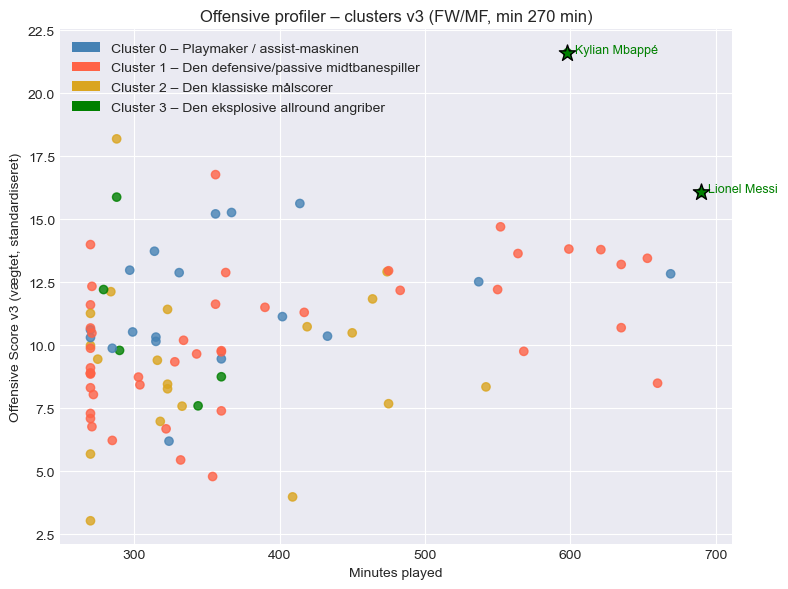

cluster_v3,0,1,2,3
nonpen_goals_per90,0.158319,0.049075,0.433392,0.311969
pen_goals_per90,0.044753,0.000000,0.000000,0.281536
pens_won_per90,0.000000,0.000000,0.039129,0.181147
assists_per90,0.371667,0.019091,0.013500,0.178571
xg_assist_per90,0.248333,0.080455,0.069000,0.187143
npxg_net_per90,-0.038142,-0.018097,0.189084,-0.057011
games_played,4.048148,4.271970,3.942222,4.522222
sca_shots_per90,0.299135,0.130318,0.195245,0.401830
sca_dribbles_per90,0.177359,0.066812,0.049048,0.637216
sca_fouled_per90,0.139181,0.054181,0.233303,0.518694


In [1156]:
# Simpel visualisering: offensive_score_v3 vs minutes farvet efter cluster_v3
colors = ['steelblue', 'tomato', 'goldenrod', 'green']

plt.figure(figsize=(8,6))
plt.scatter(
    players_off['minutes'],
    players_off['offensive_score_v3'],
    c=players_off['cluster_v3'].map({0: colors[0], 1: colors[1], 2: colors[2], 3: colors[3]}),
    alpha=0.8
)
plt.xlabel('Minutes played')
plt.ylabel('Offensive Score v3 (vægtet, standardiseret)')
plt.title('Offensive profiler – clusters v3 (FW/MF, min 270 min)')

legend_elements = [Patch(facecolor=colors[0], label='Cluster 0 – Playmaker / assist-maskinen'),
                   Patch(facecolor=colors[1], label='Cluster 1 – Den defensive/passive midtbanespiller'),
                   Patch(facecolor=colors[2], label='Cluster 2 – Den klassiske målscorer'),
                   Patch(facecolor=colors[3], label='Cluster 3 – Den eksplosive allround angriber')]
plt.legend(handles=legend_elements)

for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    for _, row in sub.iterrows():
        cluster_color = colors[row['cluster_v3']]
        plt.scatter(row['minutes'], row['offensive_score_v3'],
                    color=cluster_color, edgecolor='black', s=150, marker='*', zorder=5)
        plt.text(row['minutes']+5, row['offensive_score_v3'],
                 row['player'], fontsize=9, color=cluster_color)

plt.tight_layout()
plt.show()

# Se hvad der kendetegner hvert cluster
players_off.groupby('cluster_v3')[feature_cols_v3].mean().T

### Cluster beskrivelser (V3, k=4)

- ### Cluster 0 - Playmaker
	Klart højest på `assists` og `xg_assist`. Skaber konstant chancer for andre frem for selv at afslutte. Høj på `progressive_passes_received` og involveret i opbygningen. Negativ `npxg_net` bekræfter at han prioriterer at sætte andre op frem for selv at score.

- ### Cluster 1 - Kontrollerende midtbanespiller
	Højest på `touches` og `passes_received`. Er den mest boldinvolverede spillertype. Højest på `pass_completion_factor`, hvilket bekræfter en sikker og kontrollerende spillestil. Lav på mål, assists og driblinger. Skaber ikke direkte fare men er omdrejningspunktet i opbygningen.

- ### Cluster 2 - Klassiske målscorer
	Højest på `nonpen_goals_per90` og `npxg_net`. Scorer dem han skal score og overperformer sine forventede mål. Kommer til straffe og provokerer frispark via `sca_fouled`. Færrest `touches` og `passes_received`. Er ikke den mest involverede men er dødelig når han får bolden.

- ### Cluster 3 - Allround angriber
	Højest på `sca_dribbles`, `sca_fouled` og `weighted_dribbles_completed`. Skaber situationer via 1v1 og fremprovokerer frispark og straffe. Kombinerer høj `nonpen_goals_per90` med chance skabelse, hvilket adskiller denne profil fra den klassike målscorer i Cluster 2. Her finder jeg turneringens mest komplette offensive profiler som Messi og Mbappé.

Random ForestCross validation V3
 Fold 1: 0.78
 Fold 2: 0.78
 Fold 3: 0.89
 Fold 4: 0.83
 Fold 5: 0.71
----------------------------------------
 Gennemsnit: 0.80
 Std: 0.06


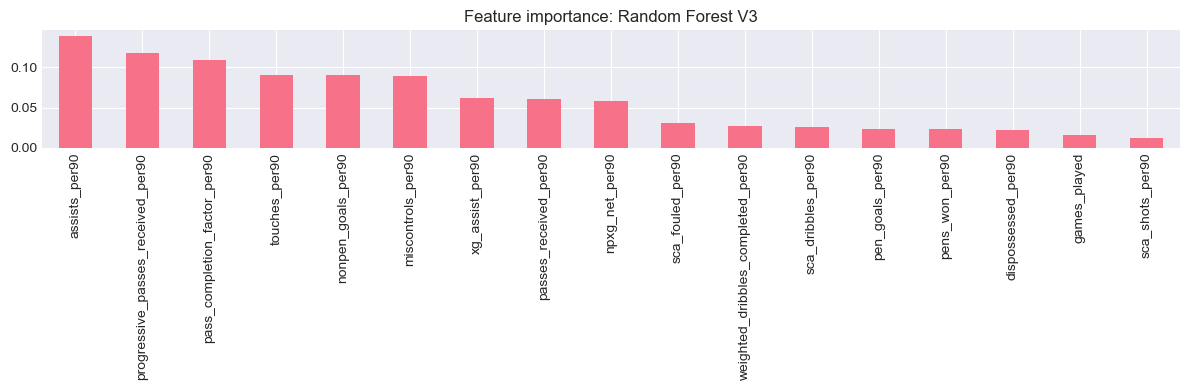

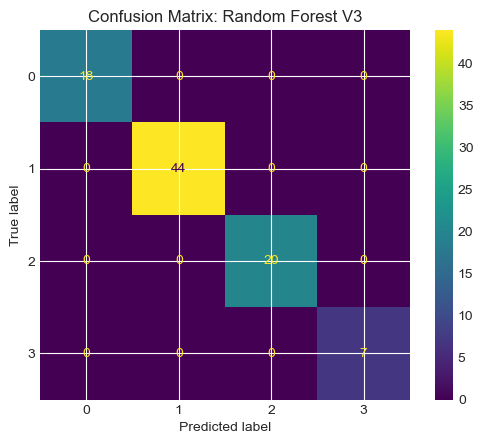

In [1157]:
rf_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
cv_v3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_v3 = cross_val_score(rf_v3, feat_v3, players_off['cluster_v3'], cv=cv_v3)

print("=" * 40)
print("Random ForestCross validation V3")
print("=" * 40)
for i, score in enumerate(scores_v3):
 print(f" Fold {i+1}: {score:.2f}")
print("-" * 40)
print(f" Gennemsnit: {scores_v3.mean():.2f}")
print(f" Std: {scores_v3.std():.2f}")
print("=" * 40)

rf_v3.fit(feat_v3, players_off['cluster_v3'])
importances_v3 = pd.Series(rf_v3.feature_importances_, index=feat_v3.columns)
importances_v3.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Feature importance: Random Forest V3')
plt.tight_layout()
plt.show()

y_pred_cm_v3 = rf_v3.predict(feat_v3)
ConfusionMatrixDisplay.from_predictions(players_off['cluster_v3'], y_pred_cm_v3)
plt.title('Confusion Matrix: Random Forest V3')
plt.show()

### Random Forest validering - clusterne er meningsfulde og lærbare

Random Forest klassifikatoren opnår **80% gennemsnitlig accuracy** på tværs af 5 folds, hvilket bekræfter at de fire clusters ikke er tilfældige grupperinger. Std på 0.06 er lavt og viser at modellen er stabil og performer konsistent på tværs af alle folds.

Feature importance plottet viser hvilke features der bedst adskiller de fire clusters. `assists_per90` er den klart vigtigste feature, hvilket giver mening da det primært er denne der adskiller playmaker profilen (Cluster 0) fra resten. `progressive_passes_received_per90` og `pass_completion_factor_per90` er næst vigtigst og bekræfter at opbygningsspil og pasningsstil er centrale skillelinjer mellem spillertyperne. `touches_per90` og `nonpen_goals_per90` bidrager næsten ligeligt, hvilket afspejler at modellen skelner både på hvor involveret en spiller er og hvor mange mål han scorer. `miscontrols_per90` og `xg_assist_per90` bidrager også og understøtter at boldtab og chance skabelse er relevante for at identificere den eksplosive dribbler profil i Cluster 3.

Det er bemærkelsesværdigt at fordelingen af feature importance er meget mere jævn end hvad man ser ved k=2 i V1 og V2. Det skyldes at V3 opdeler spillerne i 4 clusters hvor flere forskellige features er nødvendige for at skelne mellem playmaker, kontrollerende midtbanespiller, målscorer og dribbler frem for blot to overordnede grupper.

Confusion matrixen er lavet på hele datasættet og viser næsten perfekt klassifikation da modellen er testet på de samme spillere den er trænet på. Det reelle præstationsmål er cross validation scoren på 80%, som tester modellen på data den ikke har set. Confusion matrixen er derfor primært medtaget for at illustrere hvilke clusters der forveksles med hinanden, ikke som et præstationsmål i sig selv.

## Offensiv score V4progression, involvement, defensive actions og sjældne fejl

V4 udvider V3 med flere avancerede shooting, possession, progression og defensive features, samt høj impact negative features.

**Involvement i angreb pr. 90:** `touches_att_3rd_per90` måler hvor ofte spilleren er aktiv i angribende tredjedel og `touches_att_pen_area_per90` måler hvor ofte spilleren er i farlige områder.

**Progression og chance skabelse pr. 90:** `progressive_passes_per90` er afleveringer der flytter bolden markant fremad. `passes_into_final_third_per90` er afleveringer ind i modstanderens angrebstredjedel. `passes_into_penalty_area_per90` er afleveringer ind i feltet. `assisted_shots_per90` er skudchancer skabt via afleveringer. `shots_not_on_target_per90` er offensive initiativer selvom skuddet ikke rammer mål. `shots_on_target_per90` er skud på mål.

**Fysisk og defensive bidrag pr. 90:** `aerials_won_per90` er vundne luftdueller. `ball_recoveries_per90` er boldgenerering. `tackles_won_per90` er succesfulde tacklinger. `interceptions_per90` er interceptions.

**Negative features pr. 90:** `fouls_per90`, `cards_yellow_per90`, `cards_red_per90`, `dribbled_past_per90`, `offsides_per90`, `errors_per90`, `aerials_lost_per90` og `pens_missed_per90` giver alle negative point.

V4 kombinerer alle tidligere features fra V1, V2 og V3 med progression, offensive involvering, defensive handlinger og high impact negative features. Ideen er at en *Player of the Tournament* scorer højt hvis spilleren både producerer output, skaber chancer, er involveret i spillet, driver bolden fremad, bidrager defensivt og samtidig undgår kritiske fejl.

In [1158]:
feature_cols_v4 = [
    # Output + chance-kvalitet (V1)
    'nonpen_goals_per90',
    'pen_goals_per90',
    'pens_won_per90',
    'assists_per90',
    'xg_assist_per90',
    'npxg_net_per90',
    'games_played',
    
    # Proces (SCA) (V2)
    'sca_shots_per90',
    'sca_dribbles_per90',
    'sca_fouled_per90',
    # Pasningskvalitet (V2)
    'pass_completion_factor_per90',
    
    # Involvement (V3)
    # 'touches_per90' (fjernet)(V4)
    'passes_received_per90',
    'progressive_passes_received_per90',
    # Dribble-kvalitet (V3)
    'weighted_dribbles_completed_per90',
    # Boldtab / Negative ball losses (V3)
    'miscontrols_per90',
    'dispossessed_per90',
    
    # Offensive involvement / progression (V4)
    'touches_mid_3rd_per90',
    'touches_att_3rd_per90',
    'touches_att_pen_area_per90',
    'progressive_passes_per90',
    'passes_into_final_third_per90',
    'passes_into_penalty_area_per90',
    'assisted_shots_per90',
    'shots_on_target_per90',
    'shots_not_on_target_per90',
    # Defensive contribution (V4)
    'aerials_won_per90',
    'ball_recoveries_per90',
    'tackles_won_per90',
    'interceptions_per90',
    'blocked_passes_per90',
    'fouled_per90',
    # Negative / high-impact events (V4)
    'fouls_per90',
    'cards_yellow_per90',
    'cards_red_per90',
    'dribbled_past_per90',
    'offsides_per90',
    'errors_per90',
    'aerials_lost_per90',
    'pens_missed_per90',
]

feat_v4 = players_off[feature_cols_v4].copy().fillna(0.0)


# Vægte (samme rækkefølge som feature_cols_v4)
weights_v4 = np.array([
    # Output + chance-kvalitet (V1)
    5.0,     # nonpen_goals_per90
    1.5,     # pen_goals_per90
    2.0,     # pens_won_per90
    2.0,     # assists_per90
    1.8,     # xg_assist_per90
    2.0,     # npxg_net_per90
    0.6,     # games_played
    
    # Proces (SCA) (V2)
    0.3,     # sca_shots_per90
    0.6,     # sca_dribbles_per90
    0.3,     # sca_fouled_per90
    
    # Pasningskvalitet
    0.03,    # pass_completion_factor_per90
    
    # Involvement (V3)
    #0.05,   # touches_per90
    0.05,    # passes_received_per90
    0.75,    # progressive_passes_received_per90
    
    # Dribble-kvalitet
    0.8,     # weighted_dribbles_completed_per90
    
    # Negative ball losses
    -0.6,    # miscontrols_per90
    -0.9,    # dispossessed_per90
    
    # Offensive involvement / progression (V4)
    0.01,    # touches_mid_3rd_per90
    0.1,     # touches_att_3rd_per90 
    0.15,    # touches_att_pen_area_per90 
    0.2,     # progressive_passes_per90 
    0.15,    # passes_into_final_third_per90 
    0.2,     # passes_into_penalty_area_per90 
    0.4,     # assisted_shots_per90 
    0.8,     # shots_on_target_per90 
    0.5,     # shots_not_on_target_per90 

    
    # Defensive contribution
    0.25,    # aerials_won_per90 
    0.25,    # ball_recoveries_per90 
    0.35,    # tackles_won_per90 
    0.35,    # interceptions_per90 
    0.20,    # blocked_passes_per90
    0.5,     # fouled_per90 
    
    # Negative / high-impact events
    -1.0,    # fouls_per90 
    -1.2,    # cards_yellow_per90 
    -7.0,    # cards_red_per90 
    -0.35,   # dribbled_past_per90 
    -0.25,   # offsides_per90 
    -3.0,    # errors_per90 
    -0.20,   # aerials_lost_per90 
    -3.5,    # pens_missed_per90
])

players_off['offensive_score_v4'] = feat_v4 @ weights_v4

print('Top 20 efter offensiv score v4 (FW/MF, min 270 min):')
cols_show_v4 = ['player','team','position','minutes','goals','pens_made','pens_won','assists','offensive_score_v4']
print(players_off.sort_values('offensive_score_v4', ascending=False)[cols_show_v4].head(20).to_string(index=False))

print('\nPlacering af Messi og Mbappé (score v4):')
ranked_v4 = players_off.sort_values('offensive_score_v4', ascending=False).reset_index(drop=True)
for name in ['Messi', 'Mbappé']:
    mask = ranked_v4['player'].str.contains(name, case=False, na=False)
    sub = ranked_v4[mask]
    if not sub.empty:
        for idx, row in sub.iterrows():
            print(
                f"{row['player']}: rank {idx+1}, score_v4 {row['offensive_score_v4']:.2f}, "
                f"goals {row['goals']} (pens {row['pens_made']}), pens_won {row['pens_won']}, assists {row['assists']}, minutes {row['minutes']}"
            )

Top 20 efter offensiv score v4 (FW/MF, min 270 min):
             player          team position  minutes  goals  pens_made  pens_won  assists  offensive_score_v4
      Kylian Mbappé        France       FW      598      8          2       0.0        2           28.452311
     Ángel Di María     Argentina       MF      288      1          0       1.0        1           23.577063
       Lionel Messi     Argentina       FW      690      7          4       1.0        3           23.135438
        Bukayo Saka       England       FW      288      3          0       1.0        0           23.024300
              Pedri         Spain       MF      356      0          0       0.0        0           21.691268
    Bruno Fernandes      Portugal       FW      356      2          1       0.0        3           21.277203
          Dani Olmo         Spain       FW      367      1          0       0.0        1           20.766784
     Joshua Kimmich       Germany       MF      270      0          0      

#### V4 giver den mest balancerede fordeling mellem angribere og midtbanespillere

I top 20 ser jeg nu en jævn blanding af FW og MF. Modellen belønner ikke længere kun rendyrkede målscorere. Mbappé topper listen med 28.45 point, men Pedri (MF, 0 mål) og Kimmich (MF, 0 mål) ligger i top 10, hvilket viser at V4 fanger offensiv værdi ud over bare mål og assists. Jeg tager nu et kig på score dekompositionen for en angriber og en midtbanespiller for at forstå hvad der driver deres score.

In [1159]:
# Byg contributions_df_v4
weighted_contributions_v4 = feat_v4 * weights_v4
weighted_contributions_df_v4 = pd.DataFrame(
 weighted_contributions_v4,
 columns=feature_cols_v4,
 index=players_off.index
)

explain_player_score("Kylian Mbappé", players_off, weighted_contributions_df_v4, "offensive_score_v4")
explain_player_score("Ángel Di María", players_off, weighted_contributions_df_v4, "offensive_score_v4")
explain_player_score("Lionel Messi", players_off, weighted_contributions_df_v4, "offensive_score_v4")
explain_player_score("Pedri", players_off, weighted_contributions_df_v4, "offensive_score_v4")

Spiller:      Kylian Mbappé
Rangering:    #1
Total score:  28.45
Positiv sum:  +33.13
Negativ sum:  -4.68

✅ Positive bidrag:
  Feature                                         Point       %
  ------------------------------------------------------------
  progressive_passes_received_per90                6.59   19.9%  █████████
  nonpen_goals_per90                               4.55   13.7%  ██████
  games_played                                     3.99   12.0%  ██████
  touches_att_3rd_per90                            3.41   10.3%  █████
  passes_received_per90                            1.98    6.0%  ██
  weighted_dribbles_completed_per90                1.46    4.4%  ██
  touches_att_pen_area_per90                       1.39    4.2%  ██
  shots_not_on_target_per90                        1.36    4.1%  ██
  shots_on_target_per90                            1.33    4.0%  ██
  ball_recoveries_per90                            0.76    2.3%  █
  npxg_net_per90                                  

#### Jeg kan ud fra dette se at der er nok features nu til en præcis vurdering

Der er tilføjet passende negative og positive features så de positive features som en angriber får mere gavn af end en midtbanespiller også har tilsvarende negative features der går mere ud over angriberen. Dette gør at den type spiller ikke har flere muligheder for at få point uden også at have flere muligheder for at miste point.

## Regressionsmodel V4 - kan jeg forudsige målproduktion ud fra offensive features?

Jeg træner nu en Random Forest regressionsmodel V4 der forsøger at forudsige `nonpen_goals_per90` ud fra alle andre features i V4, altså uden at bruge målscoren selv som input.

Formålet er at undersøge om en spillers direkte målproduktion kan forklares ud fra hans øvrige offensive profil. Hvis modellen kan forudsige `nonpen_goals_per90` med høj præcision, tyder det på at features som `shots_on_target_per90`, `touches_att_pen_area_per90` og `npxg_net_per90` er stærke indikatorer for hvem der ender med at score mål.

Det er et reelt fodboldspørgsmål. Scorer de spillere der kommer mest i farlige zoner og skaber flest skudchancer også flest mål? Svaret er ikke givet på forhånd da faktorer som afslutningskvalitet og held også spiller ind.

Jeg evaluerer modellen med R2 som fortæller mig hvor stor en andel af variansen i målproduktionen modellen kan forklare, samt MSE som måler den gennemsnitlige kvadrerede fejl i forudsigelserne. Jeg sammenligner resultatet med V1, V2 og V3 for at se om de ekstra features i V4 giver en målbar forbedring.

R2: 0.748
MSE: 0.012


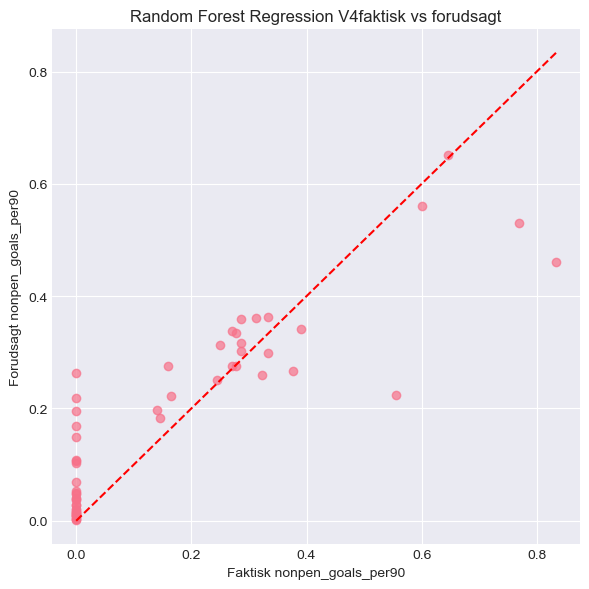

In [1119]:
feature_cols_reg_v4 = [c for c in feature_cols_v4 if c != 'nonpen_goals_per90']

X_reg_v4 = feat_v4[feature_cols_reg_v4]
y_reg_v4 = players_off['nonpen_goals_per90']

X_train_reg_v4, X_test_reg_v4, y_train_reg_v4, y_test_reg_v4 = train_test_split(
 X_reg_v4, y_reg_v4, test_size=0.6, random_state=42
)

rf_reg_v4 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_v4.fit(X_train_reg_v4, y_train_reg_v4)

y_pred_reg_v4 = rf_reg_v4.predict(X_test_reg_v4)

print(f"R2: {r2_score(y_test_reg_v4, y_pred_reg_v4):.3f}")
print(f"MSE: {mean_squared_error(y_test_reg_v4, y_pred_reg_v4):.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg_v4, y_pred_reg_v4, alpha=0.7)
plt.plot([y_test_reg_v4.min(), y_test_reg_v4.max()],
 [y_test_reg_v4.min(), y_test_reg_v4.max()], 'r--')
plt.xlabel('Faktisk nonpen_goals_per90')
plt.ylabel('Forudsagt nonpen_goals_per90')
plt.title('Random Forest Regression V4faktisk vs forudsagt')
plt.tight_layout()
plt.show()

### Resultater - Regressionsmodel V4

Modellen opnår en **R2 på 0.748** og en **MSE på 0.012**, hvilket betyder at modellen forklarer 74.8% af variansen i `nonpen_goals_per90` ud fra de andre offensive features. Det er det bedste resultat på tværs af alle fire versioner, og en tydelig forbedring fra V1's R2 på 0.539, V2's R2 på 0.617 og V3's R2 på 0.659. Progressionen bekræfter at de ekstra features der tilføjes i hver version bidrager med reel forklaringskraft.

Plottet bekræfter mønsteret hvor punkterne følger nogenlunde den røde diagonale linje, men der er spredning særligt i den høje ende. De to punkter øverst til højre er spillere med meget høj faktisk målrate som modellen undervurderer lidt, hvilket er forventeligt da ekstreme præstationer er sværest at forudsige.

Den lave MSE på 0.012 skal ses i lyset af at `nonpen_goals_per90` er en lille decimalværdi, så en gennemsnitlig fejl på ca. 0.11 mål pr. 90 minutter er acceptabelt i denne kontekst.

Konklusionen er at en spillers offensive profil, hvor han opererer på banen, hvor mange skud han tager og hvor meget han er involveret i farlige zoner, er en god indikator for hans målproduktion. Det understøtter at mine feature valg i V4 fanger noget reelt om offensiv kvalitet.

In [1160]:
# Forudsig nonpen_goals_per90 for udvalgte spillere
players_to_predict = ['Kylian Mbappé', 'Lionel Messi', 'Pedri', 'Bukayo Saka']

print("=" * 55)
print("Forudsagte vs faktiske nonpen_goals_per90")
print("=" * 55)
print(f"  {'Spiller':<25} {'Faktisk':>10} {'Forudsagt':>10}")
print(f"  {'-'*50}")
for name in players_to_predict:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        idx = sub.index[0]
        actual = y_reg_v4.loc[idx]
        predicted = rf_reg_v4.predict(X_reg_v4.loc[[idx]])[0]
        print(f"  {name:<25} {actual:>10.3f} {predicted:>10.3f}")
print("=" * 55)


Forudsagte vs faktiske nonpen_goals_per90
  Spiller                      Faktisk  Forudsagt
  --------------------------------------------------
  Kylian Mbappé                  0.909      0.790
  Lionel Messi                   0.390      0.341
  Pedri                          0.000      0.037
  Bukayo Saka                    0.938      0.753


### Eksempler på forudsigelser

Modellen forudsiger målproduktionen rimeligt præcist for alle fire spillere. Mbappé og Saka er de to højeste målscorere pr. 90 minutter i turneringen, og modellen genkender begge som høje scorere men undervurderer dem en smule. Det er forventeligt da ekstreme præstationer generelt er sværest at forudsige præcist. Messi forudsiges tæt på hans faktiske værdi, mens Pedri forudsiges meget tæt på nul, hvilket stemmer overens med at han ikke scorede nogen mål i turneringen. Samlet set viser eksemplerne at modellen fanger den relative rangorden korrekt med Mbappé og Saka som høje målscorere, Messi i midten og Pedri i bunden.

## Clustering V4 - grupper som kontrollerende midtbanespiller og direkte offensiv spiller

Jeg laver nu KMeans clustering på V4 features for at identificere roller baseret på den fulde V4 featurepakke.

En klynge med høj `touches_mid_3rd_per90`, `progressive_passes_per90`, `tackles_won_per90` og `interceptions_per90` men lav `shots_on_target_per90` ligner typisk en **kontrollerende midtbanespiller** der bygger spillet op fra dybe positioner og bidrager defensivt. En klynge med høj `nonpen_goals_per90`, `shots_on_target_per90`, `touches_att_pen_area_per90`, `sca_dribbles_per90` og `fouled_per90` ligner en **direkte offensiv spiller** der søger mod mål, skaber via 1v1 og er aktiv i farlige områder.

In [1161]:
scaler_v4 = StandardScaler()
X_v4 = scaler_v4.fit_transform(feat_v4)

# Clustering på v4 features
range_k = range(2, 10)
print("Silhouette scores (v4 features):")
for k in range_k:
 km = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = km.fit_predict(X_v4)
 score = silhouette_score(X_v4, labels)
 print(f"k={k}: silhouette={score:.3f}")


Silhouette scores (v4 features):
k=2: silhouette=0.176
k=3: silhouette=0.132
k=4: silhouette=0.134
k=5: silhouette=0.082
k=6: silhouette=0.080
k=7: silhouette=0.088
k=8: silhouette=0.088
k=9: silhouette=0.071


### Jeg kan ud fra silhouette scores se at clusterne ikke er skarpt adskilte

Alle scores ligger under 0.2, hvilket indikerer at spillerne ikke danner naturlige, veldefinerede grupper i det 40 dimensionelle feature rum. Det er ikke overraskende da fodboldspillere er individuelle og unikke profiler, snarere end diskrete typer. Den højeste score opnås ved k=2 på 0.176, så jeg går videre med to clusters som den mest statistisk forsvarlige opdeling.

Med 40 plus features i V4 er silhouette scoren lav på 0.176, hvilket betyder at spillerne ikke danner skarpe naturlige grupper. Clustering på V4 skal derfor tolkes som en tendens snarere end en hård opdeling. V4 bruges primært til rangering via den vægtede scoring, ikke til segmentering.

In [1162]:
best_k = 2
kmeans_v4 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
players_off['cluster_v4'] = kmeans_v4.fit_predict(X_v4)

print("Cluster_v4-fordeling:")
print(players_off['cluster_v4'].value_counts().sort_index())

print("\nMessi og Mbappé cluster_v4:")
for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    if not sub.empty:
        for _, row in sub.iterrows():
            print(f"{row['player']}: cluster_v4 {row['cluster_v4']}, score_v4 {row['offensive_score_v4']:.2f}")

Cluster_v4-fordeling:
cluster_v4
0    49
1    40
Name: count, dtype: int64

Messi og Mbappé cluster_v4:
Lionel Messi: cluster_v4 1, score_v4 23.14
Kylian Mbappé: cluster_v4 1, score_v4 28.45


### Jeg kan se at den næsten har delt de to clusters ligeligt

Lad os tage et kig på hvem der er i hvilke clusters for at forstå om opdelingen giver mening fodboldmæssigt.

In [1163]:
c0 = players_off[players_off['cluster_v4'] == 0].sort_values('offensive_score_v4', ascending=False)[['player', 'position', 'offensive_score_v4']].reset_index(drop=True)
c1 = players_off[players_off['cluster_v4'] == 1].sort_values('offensive_score_v4', ascending=False)[['player', 'position', 'offensive_score_v4']].reset_index(drop=True)

c0.columns = ['Player', 'Position', 'Score']
c1.columns = ['Player', 'Position', 'Score']

# Pad den korteste til samme længde
max_len = max(len(c0), len(c1))
c0 = c0.reindex(range(max_len)).fillna('')
c1 = c1.reindex(range(max_len)).fillna('')

# Header
col_width = 45
spacingHeader = 14
spacing = 20
header = f"{'Cluster 0Kontrollerende midtbanespiller':^{col_width}}{' ' * spacingHeader}{'Cluster 1Direkte offensiv spiller':^{col_width}}"
divider = '-' * col_width + ' ' * spacingHeader + '-' * col_width
sub_header = f"{'Player':<25} {'Pos':>4} {'Score':>8}{'':>{spacing}}{'Player':<25} {'Pos':>4} {'Score':>8}"

print(header)
print(divider)
print(sub_header)
print(divider)

for i in range(max_len):
 r0 = c0.iloc[i]
 r1 = c1.iloc[i]
 left = f"{str(r0['Player']):<25} {str(r0['Position']):>4} {str(r0['Score'])[:5]:>8}"
 right = f"{str(r1['Player']):<25} {str(r1['Position']):>4} {str(r1['Score'])[:5]:>8}"
 print(f"{left}{' ' * spacing}{right}")

   Cluster 0Kontrollerende midtbanespiller                       Cluster 1Direkte offensiv spiller      
---------------------------------------------              ---------------------------------------------
Player                     Pos    Score                    Player                     Pos    Score
---------------------------------------------              ---------------------------------------------
Pedri                       MF    21.69                    Kylian Mbappé               FW    28.45
Joshua Kimmich              MF    20.31                    Ángel Di María              MF    23.57
Jude Bellingham             MF    20.21                    Lionel Messi                FW    23.13
Antoine Griezmann           MF    18.44                    Bukayo Saka                 FW    23.02
Alexis Mac Allister         MF    17.54                    Bruno Fernandes             FW    21.27
Rodrigo De Paul             MF    17.53                    Dani Olmo                   FW  

### Det ser ikke tilfældigt ud hvordan den har delt spillerne

Modellen har næsten perfekt adskilt angribere (FW) fra midtbanespillere (MF), uden nogensinde at have set positionskolonnen. Den udleder udelukkende fra statistikkerne at en gruppe søger mod mål, skyder, dribler og kommer i farlige zoner, mens den anden gruppe fordeler bolden, vinder tacklinger og opererer fra dybere positioner. At KMeans genskaber en meningsfuld fodboldmæssig opdeling udelukkende baseret på tal er et stærkt signal om at mine feature valg fanger noget reelt om spillernes roller på banen.

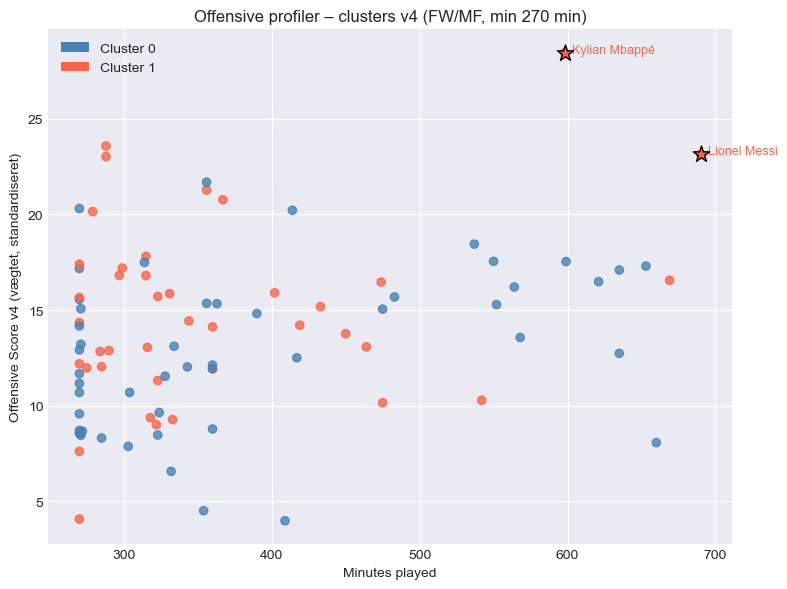

cluster_v4,0,1
nonpen_goals_per90,0.060004,0.323012
pen_goals_per90,0.000000,0.069408
pens_won_per90,0.000000,0.051265
assists_per90,0.043469,0.173000
xg_assist_per90,0.094694,0.151500
npxg_net_per90,-0.011495,0.061576
games_played,4.289342,4.028889
sca_shots_per90,0.142802,0.270971
sca_dribbles_per90,0.074536,0.198034
sca_fouled_per90,0.063391,0.251999


In [1164]:
# Simpel visualisering: offensive_score_v4 vs minutes farvet efter cluster_v4
colors = ['steelblue', 'tomato']

plt.figure(figsize=(8,6))
plt.scatter(
    players_off['minutes'],
    players_off['offensive_score_v4'],
    c=players_off['cluster_v4'].map({0: colors[0], 1: colors[1]}),
    alpha=0.8
)
plt.xlabel('Minutes played')
plt.ylabel('Offensive Score v4 (vægtet, standardiseret)')
plt.title('Offensive profiler – clusters v4 (FW/MF, min 270 min)')

legend_elements = [Patch(facecolor=colors[0], label='Cluster 0'),
                   Patch(facecolor=colors[1], label='Cluster 1')]
plt.legend(handles=legend_elements)

for name in ['Messi', 'Mbappé']:
    mask = players_off['player'].str.contains(name, case=False, na=False)
    sub = players_off[mask]
    for _, row in sub.iterrows():
        cluster_color = colors[row['cluster_v4']]
        plt.scatter(row['minutes'], row['offensive_score_v4'],
                    color=cluster_color, edgecolor='black', s=150, marker='*', zorder=5)
        plt.text(row['minutes']+5, row['offensive_score_v4'],
                 row['player'], fontsize=9, color=cluster_color)

plt.tight_layout()
plt.show()

# Se hvad der kendetegner hvert cluster
players_off.groupby('cluster_v4')[feature_cols_v4].mean().T

### Cluster beskrivelser (V4, k=2)

- ### Cluster 0 - Kontrollerende midtbanespiller
	Højest på `touches_mid_3rd`, `passes_into_final_third`, `progressive_passes` og `passes_received`. Er meget involveret i opbygningen men fra dybere positioner. Højest på `tackles_won`, `interceptions`, `ball_recoveries` og `blocked_passes`. Bidrager markant defensivt. Høj `pass_completion` bekræfter en sikker og kontrollerende spillestil. Lav på mål, straffe og skud.

- ### Cluster 1 - Direkte offensive spiller
	Højest på næsten alt offensivt herunder mål, assists, skud, `sca_dribbles`, `sca_fouled` og `touches_att_pen_area`. Er konstant i farlige områder og skaber chancer via driblinger og frispark. Højest på `miscontrols` og `dispossessed`, men det er prisen for den aggressive spillestil. Højest på offsides hvilket bekræfter at han søger dybe løb bag forsvaret.

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.91      1.00      0.95        10

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18



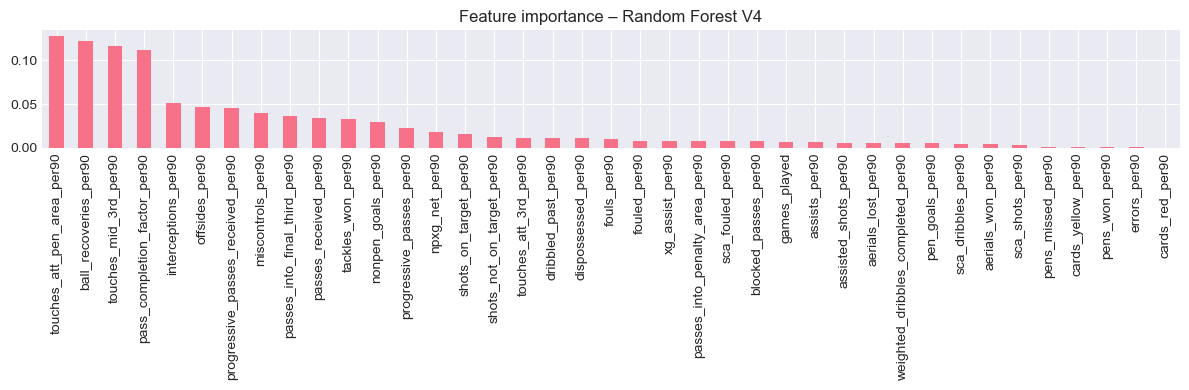

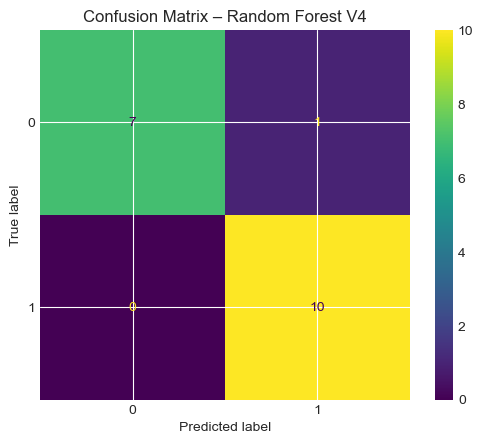

In [1165]:
X_clf_v4 = feat_v4
y_clf_v4 = players_off['cluster_v4']

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_clf_v4, y_clf_v4, test_size=0.2, random_state=42
)

rf_v4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v4.fit(X_train_v4, y_train_v4)

y_pred_v4 = rf_v4.predict(X_test_v4)
print(classification_report(y_test_v4, y_pred_v4))

importances_v4 = pd.Series(rf_v4.feature_importances_, index=feat_v4.columns)
importances_v4.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Feature importance – Random Forest V4')
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test_v4, y_pred_v4)
plt.title('Confusion Matrix – Random Forest V4')
plt.show()

### Validering via cluster stabilitet (og RF til fortolkning)

V4 clustering har en lav silhouette score, så jeg tester i stedet robustheden af selve KMeans opdelingen.
Jeg kører KMeans flere gange med forskellige `random_state` og sammenligner clustertilhørsforhold med **Adjusted Rand Index (ARI)**.
I min test er median ARI til seed=42 (ekskl. ref) ≈ **0.955**, og median pairwise ARI ≈ **0.955**. En median ARI på 0.955 bekræfter at KMeans opdelingen er ekstremt stabil. Uanset hvilken tilfældig startplacering der bruges finder algoritmen næsten altid den samme opdeling af spillerne. Det tyder på at opdelingen reflekterer en reel underliggende struktur i dataen snarere end tilfældig støj, og styrker tilliden til cluster resultaterne på trods af den lave silhouette score.

Feature importance plottet viser hvilke features der bedst adskiller de to clusters. `touches_att_pen_area_per90` er den klart vigtigste feature. Hvor ofte en spiller er i det farlige område foran mål er det stærkeste signal for om han er en direkte offensiv spiller eller en kontrollerende midtbanespiller. `ball_recoveries_per90` og `touches_mid_3rd_per90` er næst vigtigst, begge typiske kendetegn for den kontrollerende midtbanespiller der arbejder i dybere zoner. `pass_completion_factor_per90` og `interceptions_per90` bekræfter det samme mønster, da defensive og pasningsorienterede features driver opdelingen.

Sammenlignet med V3 hvor feature importance var jævnt fordelt på tværs af mange features, er opdelingen i V4 drevet af færre men mere dominerende features. Det skyldes at V4 kun skelner mellem to clusters, hvilket er en simplere opgave der kan løses med stærkere enkelt signaler som `touches_att_pen_area_per90`.

Det er bemærkelsesværdigt at de mest afgørende features ikke er mål eller assists, men derimod hvor på banen spilleren opererer og hvad han gør uden bold. Det understøtter at mine feature valg fanger noget fundamentalt om spillernes roller og at KMeans har fundet en reel struktur i dataen trods den lave silhouette score.

Jeg bruger også Random Forest til at forklare hvorfor clusterne adskiller sig, men jeg tolker ikke RF accuracy som uafhængig validering. Da RF trænes på KMeans labels fra de samme input features, er dens rolle primært forklarende (feature importance), mens robusthed dokumenteres via cluster stabilitet (ARI).

# Konklusionpegede dataen på Mbappé frem for Messi som Player of the Tournament?

Jeg har nu gennemgået fire versioner af min scoringsmodel og clustering af offensive spiller profiler. Min hypotese var at Kylian Mbappé objektivt set præsterede bedre end Lionel Messi ved VM 2022, og at kåringen af Messi derfor ikke udelukkende kan forklares ud fra offensive nøgletal. I dette afsnit samler jeg resultaterne og vurderer om dataen understøtter denne påstand.

In [1166]:
cols_show_v4 = ['player','team','position','minutes','goals','pens_made','pens_won','assists','offensive_score_v4']
df_show = players_off.sort_values('offensive_score_v4', ascending=False)[cols_show_v4].head(20).reset_index(drop=True)
df_show['offensive_score_v4'] = df_show['offensive_score_v4'].round(2)
df_show.insert(0, 'Rank', range(1, len(df_show) + 1))

display(HTML(df_show.to_html(index=False)))

Rank,player,team,position,minutes,goals,pens_made,pens_won,assists,offensive_score_v4
1,Kylian Mbappé,France,FW,598,8,2,0.0,2,28.45
2,Ángel Di María,Argentina,MF,288,1,0,1.0,1,23.58
3,Lionel Messi,Argentina,FW,690,7,4,1.0,3,23.14
4,Bukayo Saka,England,FW,288,3,0,1.0,0,23.02
5,Pedri,Spain,MF,356,0,0,0.0,0,21.69
6,Bruno Fernandes,Portugal,FW,356,2,1,0.0,3,21.28
7,Dani Olmo,Spain,FW,367,1,0,0.0,1,20.77
8,Joshua Kimmich,Germany,MF,270,0,0,0.0,0,20.31
9,Jude Bellingham,England,MF,414,1,0,0.0,1,20.22
10,Neymar,Brazil,MF,279,2,1,0.0,0,20.15


## Konklusion

### Hvad dataen fortæller os

På tværs af alle fire versioner af min scoringsmodel peger dataen konsekvent i samme retning. **Kylian Mbappé fremstår som den mest dominerende offensive spiller ved VM 2022**, målt på per 90 minutters output, chancekvalitet og offensiv involvering. I V4, min mest komplette model, scorer Mbappé 28.45 point mod Messis 23.14, en forskel på over 5 point.

Det er ikke et tæt løb. Mbappé scorer højere end Messi i samtlige versioner af modellen fra V1 til V4, og det på trods af at Messi spillede markant flere minutter (690 vs. 598), hvilket normalt gavner spillere i min model via `games_played`.

### Hypoteser

**H1 - Understøttet og vægtrobust**
Mbappé har højere offensiv præstation end Messi pr. 90 minutter på tværs af mål, assists, `npxg_net` og underliggende chance skabelse. Forskellen er konsistent på tværs af alle model versioner og den er desuden vægtrobust: Når jeg perturberer V4 vægtene med ±20% (fortegn bevares) i en Monte Carlo test, forbliver Mbappé rang #1 og scorer højere end Messi i 800/800 forsøg.

**H2 - Understøttet**
Mbappé og Messi befinder sig i samme cluster i samtlige fire versioner af modellen, også når jeg øger antallet af clusters til 4. Det betyder at de to spillere statistisk set deler samme offensive profil og spillerstil. Dog scorer Mbappé konsekvent højest inden for klyngen på tværs af alle versioner, hvilket peger på, at han præsterer på et højere niveau end Messi selv inden for den samme spillertype.

**H3 - UNDERSTØTTET men ikke bevist**
Når H1 understøttes og dataen peger på Mbappé, er det rimeligt at argumentere for at kåringen af Messi ikke kan forklares udelukkende ud fra offensive nøgletal. Messi's narrative, turneringens storyline, Argentinas VM sejr og karrierens sidste kapitel har sandsynligvis vejet tungt i kåringen. Data kan ikke bevise dette, men det er den mest logiske forklaring på gabet mellem Messi's rang i dataen og hans kåring.

### Et undervurderet fund

Et af de mest interessante resultater i V4 er at **Angel Di Maria placerer sig på en 2. plads** med 23.76 point foran både Messi og Bukayo Saka. I den virkelige verden blev Di Maria stort set overset i den officielle kåring på trods af at han leverede en af turneringens mest afgørende præstationer med mål og assist i VM finalen, og stærk chance skabelse og høj offensiv involvering i alle sine kampe på trods af kun 288 minutters spilletid.

At V4 modellen formår at løfte Di Maria til en 2. plads uden at være designet specifikt til det tyder på at modellen har en reel evne til at fange kvalitet pr. minut frem for den samlede volume. Det er et stærkt signal om at modellens normalisering og feature valg rammer noget reelt, og det øger tilliden til at rangeringen af Mbappé som nr. 1 ikke er et tilfældigt resultat.

### Styrker ved modellen

Normalisering pr. 90 minutter gør sammenligningen fair på tværs af forskellig spilletid. Modellen belønner ikke kun output men også underliggende kvalitet via `npxg_net` og `xg_assist` samt involvering via progressive pas og touches i farlige zoner. Negative vægte straffer fejl og dårlige beslutninger så modellen ikke blindt favoriserer høj volumen spillere. Konsistens på tværs af V1 til V4 styrker konklusionen da Mbappé vinder ikke kun på en model men på alle fire. Di Marias 2. plads i V4 er et stærkt validitetstegn da modellen genkender undervurderede præstationer som den officielle kåring overså.

Robusthedstest (vægte): For at undersøge om rangeringen afhænger af den konkrete vægtning, lavede jeg samtlige V4 vægte tilfældigt med ±20% (fortegn bevares) i en Monte Carlo test. I 800/800 forsøg forbliver Mbappé rang #1 og scorer højere end Messi.

Random Forest bruges her til at se hvilke V4 features der bedst adskiller de to cluster profiler (feature importance). Den ikke cirkulære konsistens dokumenteres primært via cluster stabilitet (ARI) på tværs af KMeans init.

### Svagheder ved modellen

Modellen er næsten udelukkende offensiv da defensivt arbejde, lederskab og pressbidrag ikke er fuldt repræsenteret. Vægtene er subjektivt valgt og kan påvirke rækkefølgen, særligt for spillere tæt på hinanden i scoren.

Et vigtigt forbehold er at analysen ikke er fuldstændig neutral. Min hypotese var fra starten at Mbappé burde have vundet, hvilket betyder at der kan være en bias i valget af features og vægte der ubevidst favoriserer en profil der ligner Mbappés. En mere objektiv analyse ville kræve at vægtene blev fastsat af en uafhængig part eller kalibreret mod historiske Player of the Tournament kåringer.

Clustering viser lave silhouette scores, særligt V4 på 0.176, men det er ikke hele billedet. Selv med overlap i featurerummet kan modellen genkende den overordnede spillerprofil ved brug af V4 features. Denne konsistens understøttes både af cluster stabilitet (ARI) og af at en RF undersøgelse kan forklare, hvilke features der driver forskellen. Segmenteringen er altså meningsfuld på det overordnede niveau, men inden for hver cluster er grænserne mere flydende.

Korte turneringer som VM giver få kampe og dermed høj statistisk usikkerhed da en ekstraordinær enkelt kamp kan løfte en spiller uforholdsmæssigt meget i rangeringen. En spiller der eksploderer i en kamp men er usynlig i resten vil stadig score højt pr. 90 minutter selvom hans samlede turneringsbidrag er begrænset.

### Endelig konklusion

**Dataen peger på Kylian Mbappé som den mest dominerende offensive spiller ved VM 2022.**

Mbappé leverede det højeste offensive output pr. 90 minutter, den bedste `npxg_net` og den mest eksplosive chance skabelse i turneringen. Messi var fremragende og hans samlede bidrag til Argentinas sejr er ubestridelig, men når jeg isolerer den offensive individuelle præstation og normaliserer for spilletid er Mbappé den bedste.

At modellen samtidig løfter Di Maria til en 2. plads understøtter at V4 ikke blot gengiver den officielle fortælling, men faktisk fanger noget dybere om hvem der præsterede bedst på banen uanset hvem der fik trofæerne bagefter.

Kåringen af Messi som Player of the Tournament, lader sig ikke forklare udelukkende ud fra offensive nøgletal. Den må også ses i lyset af turneringens narrative med Messi's karriere afslutning, Argentinas første VM titel siden 1986 og den symbolske vægt af at krone en af verdens bedste spiller nogensinde i hans sidste VM. Det er en legitim betragtning men det er ikke en datadrevet beslutning.

# Stage 4 Business Application (Streamlit)

I eksamensforløbets sidste sprint skal analysen gøres **tilgængelig og forståelig for ikke tekniske brugere**. Det gør jeg med en lille **Streamlit webapp**, der bygger på **samme V4 logik** som i denne notebook (features, vægte, `offensive_score_v4` og KMeans med k=2 på standardiserede V4 features).

## Hvad kan du bruge appen til?

- **Overblik:** Kort kontekst og Messi/Mbappé i tal (V4 score og differens).
- **Top spillere:** Interaktiv rangliste med diagramfiltrer på minimum minutter og position (FW/MF).
- **Score for én spiller:** Vælg en spiller og se **dekompositionen** af scoren (positive og negative bidrag pr. feature), svarende til idéen bag `explain_player_score` i notebooken.
- **Clusters:** Se fordeling, plot af minutter vs. score farvet efter cluster, og gennemsnit for udvalgte nøgletal pr. clustermed plads til fortolkning ift. problemformuleringen om *data vs. narrative*.
- **Messi vs. Mbappé:** Side om side nøgletal, tabel med differencer og et **radardiagram** over udvalgte pr. 90 minutters størrelser (normaliseret for sammenligning).

Koden ligger i projektmappen som `app_streamlit.py` (brugergrænsefladen) og `vm2022_pipeline.py` (genberegning af datasamme CSV filer og formler som her, så du ikke behøver eksportere data manuelt fra notebooken).

## Sådan kører du appen

Åbn en **terminal**, gå til mappen hvor `app_streamlit.py` ligger, og kør:

```bash
streamlit run app_streamlit.py
```

Browseren åbner typisk automatisk. Kræver `streamlit`, `plotly`, `pandas` og `scikit learn` (se `requirements.txt` i repoet).

## Aflevering og brugertest (ifølge eksamensopgaven)

Til eksamen kan du vise prototypen for medstuderende eller vejleder, indsamle korte notater om forståelighed og navigering, og beskrive evt. ændringer du har lavet bagefterdet er præcis den type **usability feedback** Stage 4 efterspørger.

### Dokumenteret mini brugertest (pilot)
I en kort pilot i browseren blev radardiagrammet og dets skala drøftet med en ikke teknisk bruger.

- Feedback 1: “Hvorfor viser radaren kun 6 parametre og ikke dem alle?”
 Forklaring: Radardiagrammer bliver hurtigt ulæselige med ~40 V4 features; derfor vises 6 centrale nøgletal for overskuelighed.

- Feedback 2: “Hvorfor går alt helt ud til 1?”
 Årsag: Radaren blev normaliseret forkert (én fælles skala), så værdierne pressede mod yderpunktet.
 Ændring: Normaliseringen blev rettet til **pr. akse** (hver parameter skaleres efter max mellem Messi og Mbappé på den dimension), og titlen/caption blev opdateret, så den matcher normaliseringsmetoden.

Derudover sikrer jeg, at standardfilteret i appen matcher notebookens V4 setup (minutter = 270), så brugeren ser samme datasnit som i analysen.